# TLC Trip Data - Exploratory Analysis

Tasks 1–5: Schema · Nulls · FHV Sparsity · Fleet Mix · Temporal Patterns

**Fleet grouping model:** Yellow + Green form the **metered group** (taximeter, fixed fares). FHV + FHVHV form the **dispatched group** (app-based, dynamic pricing). Cross-group field comparisons (fare, distance) are only valid after explicit normalization. Zone IDs and timestamps are directly comparable across groups.

In [1]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

RAW = Path("../data/raw/tlc_trips")

# Fleet files
FLEET = {
    "yellow": RAW / "yellow_tripdata_2025-01.parquet",
    "green":  RAW / "green_tripdata_2025-01.parquet",
    "fhv":    RAW / "fhv_tripdata_2025-01.parquet",
    "fhvhv":  RAW / "fhvhv_tripdata_2025-01.parquet",
}

# Two operationally distinct groups — analysis respects this split
METERED    = ["yellow", "green"]   # taximeter, fixed fares, passenger_count
DISPATCHED = ["fhv", "fhvhv"]     # app-based, dynamic pricing, no passenger_count

# Canonical pickup datetime column per fleet
PICKUP_COL = {
    "yellow": "tpep_pickup_datetime",
    "green":  "lpep_pickup_datetime",
    "fhv":    "pickup_datetime",
    "fhvhv":  "pickup_datetime",
}

# Canonical dropoff datetime column per fleet
DROPOFF_COL = {
    "yellow": "tpep_dropoff_datetime",
    "green":  "lpep_dropoff_datetime",
    "fhv":    "dropOff_datetime",
    "fhvhv":  "dropoff_datetime",
}

# Colors: consistent per fleet across all plots
FLEET_COLORS = {
    "yellow": "#f6c90e",
    "green":  "#4caf50",
    "fhv":    "#7986cb",
    "fhvhv":  "#ef5350",
}

# Group-level colors for cross-group plots
GROUP_COLORS = {"metered": "#2196f3", "dispatched": "#ff5722"}

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## Task 1 - Schema Harmonization

Three-part analysis using pyarrow (zero data loaded):
1. **Metered group** — Yellow vs Green: shared fields, fleet-specific fields, poolability verdict
2. **Dispatched group** — FHV vs FHVHV: structural absences vs recoverable fields
3. **Cross-group common core** — only the fields genuinely comparable across groups (zone IDs, timestamps)

In [2]:
# Read schemas without loading data
schemas = {name: pq.read_schema(path) for name, path in FLEET.items()}

def schema_table(fleet_names):
    """
    Build a dtype comparison table for a subset of fleets.
    """
    rows = {}
    for name in fleet_names:
        for field in schemas[name]:
            rows.setdefault(field.name, {})[name] = str(field.type)
    return (
        pd.DataFrame(rows).T
            .reindex(columns=fleet_names)
            .fillna("—")
            .rename_axis("column")
    )

# Part 1: Metered group
metered_df = schema_table(METERED)
print("METERED GROUP (Yellow vs Green)")
display(metered_df.style.apply(
    lambda col: ["background-color: #fff9c4" if v == "—" else "" for v in col], axis=0
))

shared_m   = [c for c in metered_df.index if (metered_df.loc[c] != "—").all()]
yellow_only = [c for c in metered_df.index if metered_df.loc[c, "green"] == "—"]
green_only  = [c for c in metered_df.index if metered_df.loc[c, "yellow"] == "—"]
print(f"\nShared ({len(shared_m)}):      {shared_m}")
print(f"Yellow-only ({len(yellow_only)}): {yellow_only}")
print(f"Green-only ({len(green_only)}):  {green_only}")

METERED GROUP (Yellow vs Green)


,yellow,green
column,,
VendorID,int32,int32
tpep_pickup_datetime,timestamp[us],—
tpep_dropoff_datetime,timestamp[us],—
passenger_count,int64,int64
trip_distance,double,double
RatecodeID,int64,int64
store_and_fwd_flag,large_string,large_string
PULocationID,int32,int32
DOLocationID,int32,int32



Shared (17):      ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'cbd_congestion_fee']
Yellow-only (3): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'Airport_fee']
Green-only (4):  ['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'ehail_fee', 'trip_type']


In [3]:
# Part 2: Dispatched group
dispatched_df = schema_table(DISPATCHED)
print("DISPATCHED GROUP (FHV vs FHVHV)")
display(dispatched_df.style.apply(
    lambda col: ["background-color: #fff9c4" if v == "—" else "" for v in col], axis=0
))

shared_d  = [c for c in dispatched_df.index if (dispatched_df.loc[c] != "—").all()]
fhv_only  = [c for c in dispatched_df.index if dispatched_df.loc[c, "fhvhv"] == "—"]
fhvhv_only = [c for c in dispatched_df.index if dispatched_df.loc[c, "fhv"] == "—"]
print(f"\nShared ({len(shared_d)}):       {shared_d}")
print(f"FHV-only ({len(fhv_only)}):     {fhv_only}")
print(f"FHVHV-only ({len(fhvhv_only)}): {fhvhv_only}")

DISPATCHED GROUP (FHV vs FHVHV)


,fhv,fhvhv
column,,
dispatching_base_num,large_string,large_string
pickup_datetime,timestamp[us],timestamp[us]
dropOff_datetime,timestamp[us],—
PUlocationID,int64,—
DOlocationID,int64,—
SR_Flag,int64,—
Affiliated_base_number,large_string,—
hvfhs_license_num,—,large_string
originating_base_num,—,large_string



Shared (2):       ['dispatching_base_num', 'pickup_datetime']
FHV-only (5):     ['dropOff_datetime', 'PUlocationID', 'DOlocationID', 'SR_Flag', 'Affiliated_base_number']
FHVHV-only (23): ['hvfhs_license_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']


In [4]:
# Part 3: Cross-group common core
# Only zone IDs and timestamps are directly comparable across groups.
# Fare and distance fields are analogous but not equivalent.
CROSS_GROUP_CORE = pd.DataFrame([
    {
        "concept":        "pickup zone",
        "metered":        "PULocationID (int32)",
        "dispatched":     "PULocationID (int32) / PUlocationID float in fhv",
        "comparable":     "Yes — same 263-zone TLC system; fhv needs float→int cast",
    },
    {
        "concept":        "dropoff zone",
        "metered":        "DOLocationID (int32)",
        "dispatched":     "DOLocationID (int32) / DOlocationID float in fhv",
        "comparable":     "Yes — same caveat as above",
    },
    {
        "concept":        "pickup time",
        "metered":        "tpep_*/lpep_pickup_datetime",
        "dispatched":     "pickup_datetime",
        "comparable":     "Yes — same moment semantics, same timezone",
    },
    {
        "concept":        "dropoff time",
        "metered":        "tpep_*/lpep_dropoff_datetime",
        "dispatched":     "dropOff_datetime (fhv) / dropoff_datetime (fhvhv)",
        "comparable":     "Yes — same caveat as above",
    },
    {
        "concept":        "base fare",
        "metered":        "fare_amount (taximeter rate)",
        "dispatched":     "base_passenger_fare (dynamic pricing, fhvhv only)",
        "comparable":     "Analogous, NOT equivalent — different pricing models",
    },
    {
        "concept":        "trip distance",
        "metered":        "trip_distance (taximeter-reported, miles)",
        "dispatched":     "trip_miles (GPS-based, fhvhv only; absent in fhv)",
        "comparable":     "Same unit (miles), different measurement method",
    },
    {
        "concept":        "congestion surcharge",
        "metered":        "congestion_surcharge + cbd_congestion_fee",
        "dispatched":     "congestion_surcharge + cbd_congestion_fee (fhvhv only)",
        "comparable":     "Yes for fhvhv; absent in fhv",
    },
]).set_index("concept")

display(CROSS_GROUP_CORE)

,metered,dispatched,comparable
concept,,,
pickup zone,PULocationID (int32),PULocationID (int32) / PUlocationID float in fhv,Yes — same 263-zone TLC system; fhv needs floa...
dropoff zone,DOLocationID (int32),DOLocationID (int32) / DOlocationID float in fhv,Yes — same caveat as above
pickup time,tpep_*/lpep_pickup_datetime,pickup_datetime,"Yes — same moment semantics, same timezone"
dropoff time,tpep_*/lpep_dropoff_datetime,dropOff_datetime (fhv) / dropoff_datetime (fhvhv),Yes — same caveat as above
base fare,fare_amount (taximeter rate),"base_passenger_fare (dynamic pricing, fhvhv only)","Analogous, NOT equivalent — different pricing ..."
trip distance,"trip_distance (taximeter-reported, miles)","trip_miles (GPS-based, fhvhv only; absent in fhv)","Same unit (miles), different measurement method"
congestion surcharge,congestion_surcharge + cbd_congestion_fee,congestion_surcharge + cbd_congestion_fee (fhv...,Yes for fhvhv; absent in fhv


In [5]:
# Part 4: Data snapshot — first 5 rows of yellow and green
# SNAPSHOT_COLS = 10  # cap columns for readability

for fleet in METERED:
    sample = (
        pq.read_table(FLEET[fleet])
        .slice(0, 5)
        .to_pandas()
    )
    print(f"\n{'─' * 60}")
    # print(f"  {fleet.upper()}  ({sample.shape[1]} columns, showing first {SNAPSHOT_COLS})")
    print(f"  {fleet.upper()}  ({sample.shape[1]} columns)")
    print(f"{'─' * 60}")
    # display(sample.iloc[:, :SNAPSHOT_COLS])
    display(sample)


────────────────────────────────────────────────────────────
  YELLOW  (20 columns)
────────────────────────────────────────────────────────────


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1,1.60,1,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1,0.50,1,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1,0.60,1,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3,0.52,1,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3,0.66,1,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0



────────────────────────────────────────────────────────────
  GREEN  (21 columns)
────────────────────────────────────────────────────────────


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1,75,235,1,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1,1,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1,166,75,1,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2,1,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5,171,73,1,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2,2,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1,74,223,1,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1,1,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1,66,158,1,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1,1,2.75,0.0


**Key Finding — Schema Harmonization**

**Metered group (yellow + green):** 17 shared fields with identical types. Fleet-specific columns are minor — yellow has `Airport_fee`; green has `ehail_fee` (100% null) and `trip_type`. Datetime columns differ only by prefix (`tpep_` vs `lpep_`). **Verdict: poolable** after renaming datetimes and dropping or NaN-filling the 3+4 fleet-specific columns.

**Dispatched group (FHV vs FHVHV):** Only 2 shared fields (`dispatching_base_num`, `pickup_datetime`). FHVHV has 23 unique fields including fare, distance, and shared-ride signals that FHV lacks entirely. These are structurally different datasets, not variants of the same schema. **FHVHV is the only operative dispatched-group source.**

**Cross-group common core:** Zone IDs (`PULocationID`/`DOLocationID`) and timestamps are directly comparable across groups — same 263-zone system, same timezone. `fare_amount` ↔ `base_passenger_fare` are analogous but not equivalent (metered rate vs dynamic pricing). `trip_distance` ↔ `trip_miles` share the same unit (miles) but differ in measurement method (taximeter vs GPS). Any cross-group feature must normalize for these differences explicitly in Stage 2.

## Task 2 - Null / Missing Value Audit

Per-column null rates for every file. Heatmap **columns ordered by fleet group** (metered first, dispatched second) so structural absences (fhv's missing fare/distance fields) are visually distinct from data quality issues.

In [6]:
null_rates = {}
row_counts = {}

for fleet, path in FLEET.items():
    df = pd.read_parquet(path)
    row_counts[fleet] = len(df)
    null_rates[fleet] = (df.isnull().mean() * 100).round(1)

# Column order: metered group first, dispatched group second
GROUP_ORDER = METERED + DISPATCHED
null_df = pd.DataFrame(null_rates).reindex(columns=GROUP_ORDER).fillna(float("nan"))
null_df.index.name = "column"

# Flag columns with >=10% nulls in at least one fleet
HIGH_NULL = 10.0
flagged = (null_df >= HIGH_NULL).any(axis=1)
if flagged.any():
    print(f"Columns with >={HIGH_NULL}% nulls in at least one fleet:")
    display(null_df[flagged].style
            .background_gradient(axis=None, cmap="Reds", vmin=0, vmax=100)
            .format("{:.1f}%", na_rep="—"))
else:
    print(f"No columns exceed {HIGH_NULL}% nulls in any fleet (excluding structurally absent fields shown as '—').")

Columns with >=10.0% nulls in at least one fleet:


,yellow,green,fhv,fhvhv
column,,,,
Airport_fee,15.5%,—,—,—
DOlocationID,—,—,16.1%,—
PUlocationID,—,—,83.0%,—
RatecodeID,15.5%,3.8%,—,—
SR_Flag,—,—,100.0%,—
congestion_surcharge,15.5%,3.8%,—,0.0%
ehail_fee,—,100.0%,—,—
on_scene_datetime,—,—,—,24.7%
originating_base_num,—,—,—,24.7%


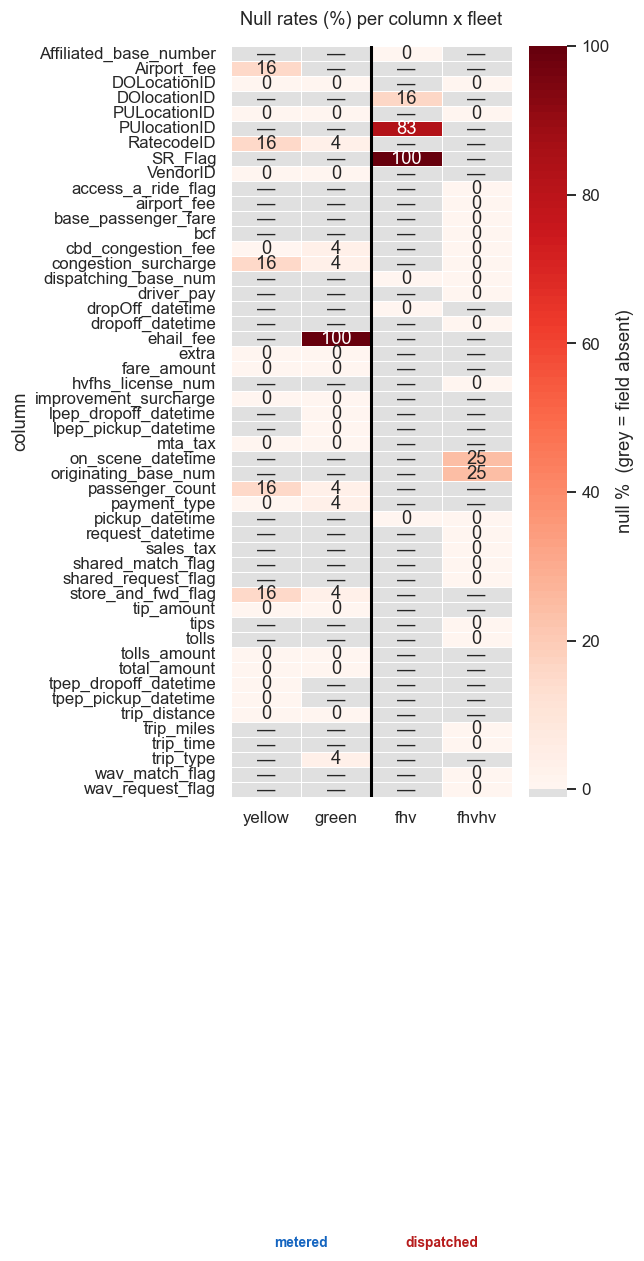

In [7]:
# Null heatmap — columns grouped: metered | dispatched
# NaN cells (field absent from that fleet) rendered in light grey to distinguish
# structural absences from real null rates
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(6, max(4, len(null_df) * 0.28)))

# Build a numeric matrix; use -1 as sentinel for "field absent"
plot_data = null_df.copy().fillna(-1)

# Custom colormap: grey for absent (-1), white-to-red for 0-100
cmap_base = plt.cm.Reds
colors_list = [(0.88, 0.88, 0.88)] + [cmap_base(i / 100) for i in range(101)]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("grey_reds", colors_list, N=102)

annot_labels = plot_data.map(lambda v: "—" if v == -1 else f"{v:.0f}")  # pandas 2.x: map not applymap

sns.heatmap(
    plot_data,
    annot=annot_labels,
    fmt="s",
    cmap=custom_cmap,
    vmin=-1, vmax=100,
    linewidths=0.4,
    cbar_kws={"label": "null %  (grey = field absent)"},
    ax=ax,
)

# Vertical separator between metered and dispatched groups
ax.axvline(len(METERED), color="black", linewidth=2)
ax.text(len(METERED) / 2, -0.6, "metered", ha="center", fontsize=9, color="#1565c0", fontweight="bold",
        transform=ax.get_xaxis_transform())
ax.text(len(METERED) + len(DISPATCHED) / 2, -0.6, "dispatched", ha="center", fontsize=9,
        color="#b71c1c", fontweight="bold", transform=ax.get_xaxis_transform())

ax.set_title("Null rates (%) per column x fleet", pad=14)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Key Finding — Null / Missing Value Audit**

11 columns exceed the 10% null threshold in at least one fleet. The pattern separates cleanly into three categories:

1. **Structural absences (expected):** FHV's `SR_Flag` (100% null — field exists but was never populated), green's `ehail_fee` (100% null — deprecated). These are not data quality problems; they are schema artifacts. FHV's `PUlocationID` at 83% null is likewise structural — most base operators do not report pickup location.

2. **Vendor-correlated nulls in yellow:** `passenger_count`, `RatecodeID`, `Airport_fee`, `store_and_fwd_flag`, and `congestion_surcharge` are all ~15.5% null. The identical rate strongly suggests a single meter vendor omits these fields. Stage 2 should filter by `VendorID` or impute per-vendor rather than dropping 15% of yellow rows.

3. **Partial coverage in FHVHV:** `on_scene_datetime` and `originating_base_num` are ~24.7% null — likely Lyft trips (24.7% of FHVHV) that don't report these fields. Not blocking for core zone/time features but limits wait-time signal to Uber trips.

## Task 3 - FHV Location Sparsity Decision Gate

FHV is the only fleet where location IDs appeared `NaN` in the first rows. Determine whether it can contribute to zone-based mobility features.

In [8]:
# Load only the columns needed for this gate
fhv = pd.read_parquet(
    FLEET["fhv"],
    columns=["dispatching_base_num", "PUlocationID", "DOlocationID"],
)

pu_pct = fhv["PUlocationID"].notna().mean() * 100
do_pct = fhv["DOlocationID"].notna().mean() * 100
print(f"FHV PUlocationID non-null: {pu_pct:.1f}%")
print(f"FHV DOlocationID non-null: {do_pct:.1f}%")

THRESHOLD = 30.0
verdict = "INCLUDE (location data sufficient)" if pu_pct >= THRESHOLD else "EXCLUDE from zone-based features (too sparse)"
print(f"\nDecision gate (threshold={THRESHOLD}%): {verdict}")

FHV PUlocationID non-null: 17.0%
FHV DOlocationID non-null: 83.9%

Decision gate (threshold=30.0%): EXCLUDE from zone-based features (too sparse)


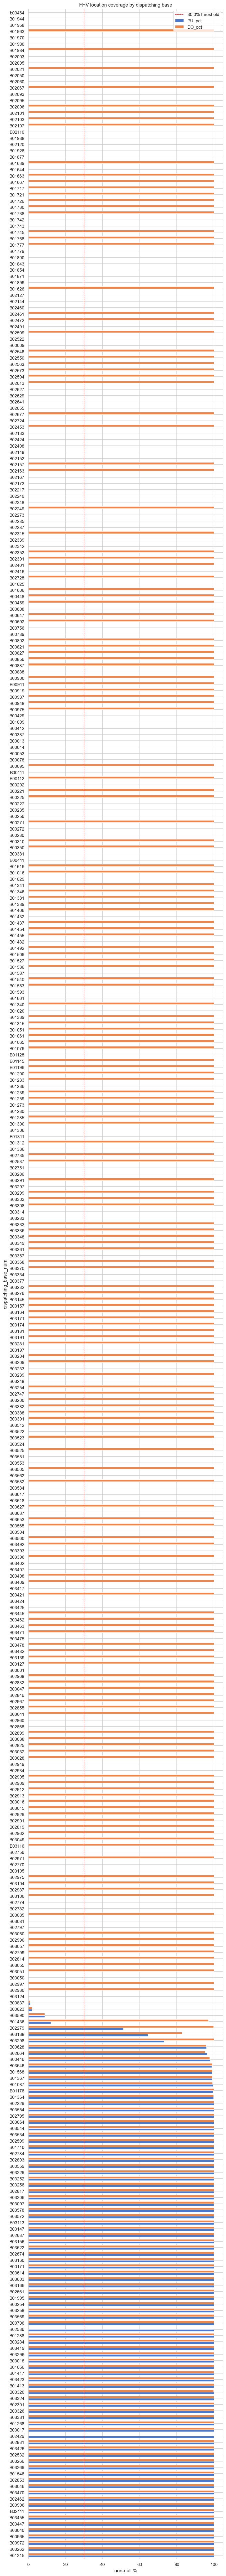

In [9]:
# Per-base location coverage — surface which operators have data
base_coverage = (
    fhv.groupby("dispatching_base_num")[["PUlocationID", "DOlocationID"]]
    .apply(lambda g: (g.notna().mean() * 100).round(1))
    .rename(columns={"PUlocationID": "PU_pct", "DOlocationID": "DO_pct"})
    .sort_values("PU_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(3, len(base_coverage) * 0.22)))
base_coverage[["PU_pct", "DO_pct"]].plot(kind="barh", ax=ax, width=0.7)
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"{THRESHOLD}% threshold")
ax.set_xlabel("non-null %")
ax.set_title("FHV location coverage by dispatching base")
ax.legend()
plt.tight_layout()
plt.show()

del fhv  # free memory

**Key Finding — FHV Location Sparsity Decision Gate**

`PUlocationID` is 17.0% non-null — well below the 30% threshold. **FHV is excluded from zone-based features.**

`DOlocationID` is 83.9% non-null, so the bottleneck is pickup location specifically. The per-base breakdown shows no sub-operator cluster with consistently usable PU data — the sparsity is systemic, not confined to a few bases. Combined with FHV's structural absence of fare and distance fields (Task 1), the ~320K trips with usable PU zones do not justify the engineering cost of a partially-useful dataset. FHV is dropped from all downstream stages.

## Task 4 - Fleet Mix & Volume Overview

Three-level breakdown: group totals → within-group shares → FHVHV platform split.
Green and FHV must be read in relation to their own group, not against fhvhv directly.

Group               Trips    Share
----------------------------------
metered         3,523,552    13.6%
dispatched     22,303,774    86.4%
TOTAL          25,827,326  100.0%

Within-group fleet breakdown:
  metered
    yellow      3,475,226    98.6% of group
    green          48,326     1.4% of group
  dispatched
    fhv         1,898,108     8.5% of group
    fhvhv      20,405,666    91.5% of group


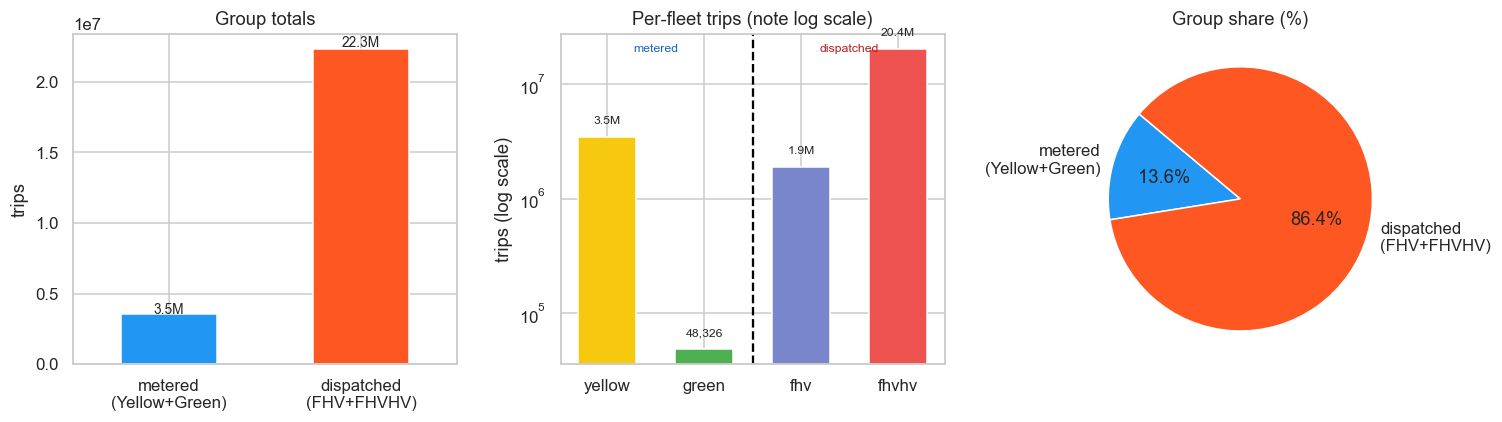

In [10]:
# row_counts populated in Task 2
metered_total    = sum(row_counts[f] for f in METERED)
dispatched_total = sum(row_counts[f] for f in DISPATCHED)
grand_total      = metered_total + dispatched_total

group_totals = pd.Series({"metered": metered_total, "dispatched": dispatched_total}, name="trips")

print(f"{'Group':<12} {'Trips':>12}  {'Share':>7}")
print("-" * 34)
for g, n in group_totals.items():
    print(f"{g:<12} {n:>12,}  {n/grand_total*100:>6.1f}%")
print(f"{'TOTAL':<12} {grand_total:>12,}  100.0%")

print("\nWithin-group fleet breakdown:")
for group, fleets in [("metered", METERED), ("dispatched", DISPATCHED)]:
    gtotal = group_totals[group]
    print(f"  {group}")
    for f in fleets:
        n = row_counts[f]
        print(f"    {f:<8} {n:>12,}  {n/gtotal*100:>6.1f}% of group")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: group totals
group_totals.plot(kind="bar", ax=axes[0],
                  color=[GROUP_COLORS["metered"], GROUP_COLORS["dispatched"]], width=0.5)
axes[0].set_title("Group totals")
axes[0].set_ylabel("trips")
axes[0].set_xticklabels(["metered\n(Yellow+Green)", "dispatched\n(FHV+FHVHV)"], rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f"{bar.get_height()/1e6:.1f}M", ha="center", fontsize=9)

# Panel 2: within-group shares (side-by-side, same axis is misleading — split by group color)
all_fleets_ordered = METERED + DISPATCHED
fleet_trips = [row_counts[f] for f in all_fleets_ordered]
bar_colors = [FLEET_COLORS[f] for f in all_fleets_ordered]
bars = axes[1].bar(all_fleets_ordered, fleet_trips, color=bar_colors, width=0.6)
axes[1].set_title("Per-fleet trips (note log scale)")
axes[1].set_yscale("log")
axes[1].set_ylabel("trips (log scale)")
axes[1].axvline(1.5, color="black", linewidth=1.5, linestyle="--")
axes[1].text(0.5, axes[1].get_ylim()[1] * 0.7, "metered", ha="center", fontsize=8, color="#1565c0")
axes[1].text(2.5, axes[1].get_ylim()[1] * 0.7, "dispatched", ha="center", fontsize=8, color="#b71c1c")
for bar, fleet in zip(bars, all_fleets_ordered):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.3,
                 f"{row_counts[fleet]/1e6:.1f}M" if row_counts[fleet] > 1e5 else f"{row_counts[fleet]:,}",
                 ha="center", fontsize=8)

# Panel 3: group share pie
axes[2].pie(group_totals, labels=["metered\n(Yellow+Green)", "dispatched\n(FHV+FHVHV)"],
            autopct="%1.1f%%",
            colors=[GROUP_COLORS["metered"], GROUP_COLORS["dispatched"]], startangle=140)
axes[2].set_title("Group share (%)")

plt.tight_layout()
plt.show()

                      trips  share_pct
hvfhs_license_num                     
Uber               15356455       75.3
Lyft                5049211       24.7


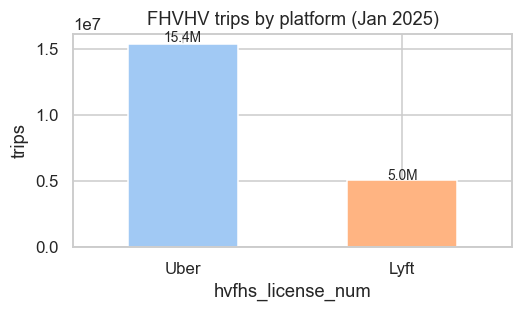

In [11]:
# FHVHV platform breakdown — load only the license column
PLATFORM_NAMES = {
    "HV0002": "Juno",
    "HV0003": "Uber",
    "HV0004": "Via",
    "HV0005": "Lyft",
}

fhvhv_license = pd.read_parquet(FLEET["fhvhv"], columns=["hvfhs_license_num"])
platform_counts = (
    fhvhv_license["hvfhs_license_num"]
    .map(PLATFORM_NAMES)
    .value_counts()
    .rename("trips")
    .to_frame()
    .assign(share_pct=lambda d: (d["trips"] / d["trips"].sum() * 100).round(1))
)
print(platform_counts.to_string())

fig, ax = plt.subplots(figsize=(5, 3))
platform_counts["trips"].plot(kind="bar", ax=ax, color=sns.color_palette("pastel", len(platform_counts)))
ax.set_title("FHVHV trips by platform (Jan 2025)")
ax.set_ylabel("trips")
ax.set_xticklabels(platform_counts.index, rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{bar.get_height()/1e6:.1f}M", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

del fhvhv_license

**Key Finding — Fleet Mix & Volume Overview**

The dispatched group accounts for 86.4% of all trips (22.3M) versus metered's 13.6% (3.5M) — a 6:1 ratio. Within each group the asymmetry is even starker:

- **Metered:** Yellow is 98.6% (3.48M); green is 1.4% (48K). Green's volume is negligible — pooling adds no meaningful new signal but is harmless if schemas align (Task 1 confirms they do).
- **Dispatched:** FHVHV is 91.5% (20.4M); FHV is 8.5% (1.9M). FHV is already excluded (Task 3).
- **FHVHV platform split:** Uber 75.3% (15.4M), Lyft 24.7% (5.0M). This 3:1 ratio aligns with the ~24.7% null rate in `on_scene_datetime` (Task 2), confirming that Lyft trips lack certain fields.

**Implication for Stage 1:** Excluding FHVHV would reduce the dataset from 25.8M to 3.5M trips and eliminate all outer-borough coverage. The cold-start hypothesis depends on FHVHV's volume and geographic breadth.

## Task 5 - Temporal Distributions (Hour-of-Day & Day-of-Week)

Three plots:
- **Plot A** - Metered group: yellow and green **overlaid** (normalised %). Tests poolability.
- **Plot B** - Dispatched group: fhvhv hour-of-day. fhv shown separately for reference.
- **Plot C** - Cross-group: metered aggregate vs fhvhv aggregate. Timestamps are directly comparable across groups — reveals whether the two populations have different time-of-day preferences.

Meal-time windows annotated on all plots: lunch (11–14h), dinner (17–21h), late-night (22–02h).

In [12]:
MEAL_WINDOWS = [
    ("breakfast/ work", 6, 9,   "#c7ffb2"),
    ("lunch", 11, 14,   "#ffe0b2"),
    ("dinner", 17, 21,   "#fce4ec"),
    ("late-night", 22, 24, "#e8eaf6"),
    ("late-night", 0, 2, "#e8eaf6")
]

def add_meal_shading(ax):
    for label, h_start, h_end, color in MEAL_WINDOWS:
        ax.axvspan(h_start, h_end, alpha=0.35, color=color, zorder=0)

# Load only pickup datetime per fleet
hourly = {}
dow    = {}
for fleet, path in FLEET.items():
    col = PICKUP_COL[fleet]
    s = pd.read_parquet(path, columns=[col])[col]
    hourly[fleet] = s.dt.hour.value_counts().sort_index()
    dow[fleet]    = s.dt.dayofweek.value_counts().sort_index()

# Normalise to share (%)
hourly_norm = {f: s / s.sum() * 100 for f, s in hourly.items()}
dow_norm    = {f: s / s.sum() * 100 for f, s in dow.items()}

def group_aggregate(fleets, norm_dict, counts, idx):
    """Weighted average of normalised shares across fleets, reindexed to idx."""
    total = sum(counts[f] for f in fleets)
    agg   = sum(norm_dict[f].reindex(idx, fill_value=0) * counts[f] / total for f in fleets)
    return agg

metered_agg    = group_aggregate(METERED,    hourly_norm, row_counts, range(24))
dispatched_agg = group_aggregate(["fhvhv"],  hourly_norm, row_counts, range(24))

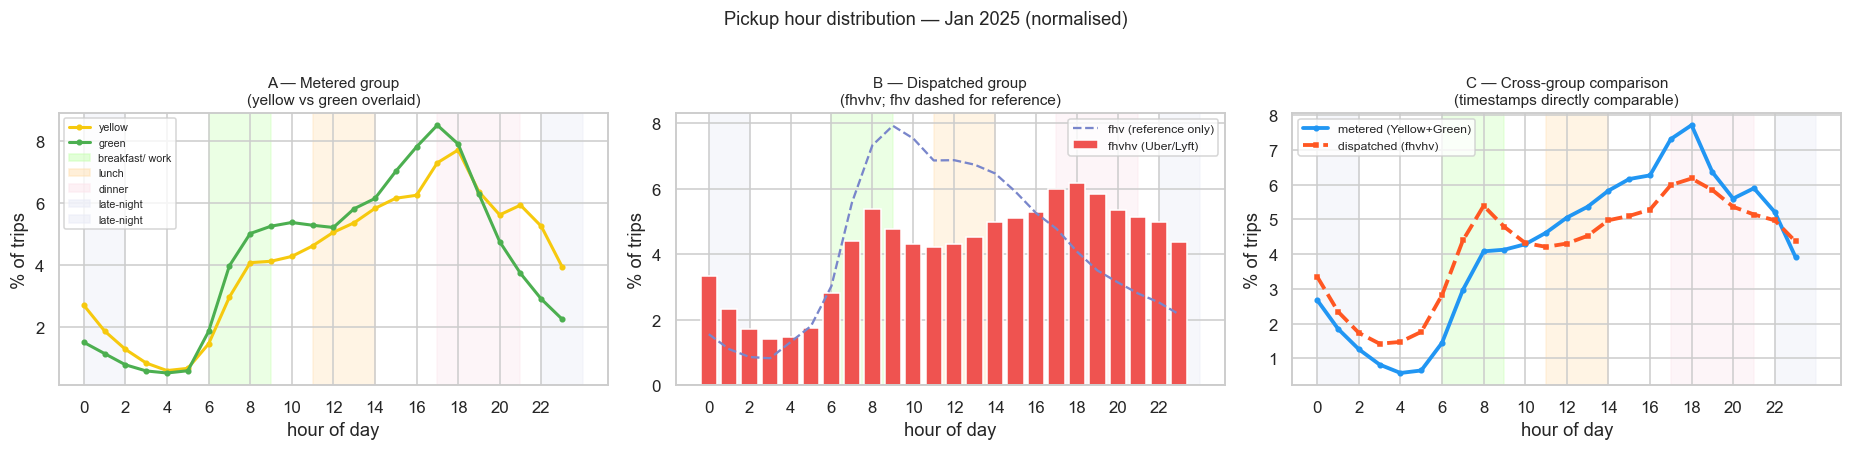

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
hours = range(24)

# Plot A: Metered group — yellow vs green overlaid
ax = axes[0]
add_meal_shading(ax)
for fleet in METERED:
    norm = hourly_norm[fleet].reindex(hours, fill_value=0)
    ax.plot(hours, norm.values, color=FLEET_COLORS[fleet], linewidth=2, label=fleet, marker="o", markersize=3)
ax.set_title("A — Metered group\n(yellow vs green overlaid)", fontsize=10)
ax.set_xlabel("hour of day")
ax.set_ylabel("% of trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

# Plot B: Dispatched group — fhvhv (fhv for reference)
ax = axes[1]
add_meal_shading(ax)
norm_fhvhv = hourly_norm["fhvhv"].reindex(hours, fill_value=0)
ax.bar(hours, norm_fhvhv.values, color=FLEET_COLORS["fhvhv"], width=0.8, label="fhvhv (Uber/Lyft)", zorder=2)
norm_fhv = hourly_norm["fhv"].reindex(hours, fill_value=0)
ax.plot(hours, norm_fhv.values, color=FLEET_COLORS["fhv"], linewidth=1.5,
        linestyle="--", label="fhv (reference only)", zorder=3)
ax.set_title("B — Dispatched group\n(fhvhv; fhv dashed for reference)", fontsize=10)
ax.set_xlabel("hour of day")
ax.set_ylabel("% of trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

# Plot C: Cross-group — metered aggregate vs fhvhv
ax = axes[2]
add_meal_shading(ax)
ax.plot(hours, metered_agg.values, color=GROUP_COLORS["metered"], linewidth=2.5,
        label="metered (Yellow+Green)", marker="o", markersize=3)
ax.plot(hours, dispatched_agg.values, color=GROUP_COLORS["dispatched"], linewidth=2.5,
        label="dispatched (fhvhv)", linestyle="--", marker="s", markersize=3)
ax.set_title("C — Cross-group comparison\n(timestamps directly comparable)", fontsize=10)
ax.set_xlabel("hour of day")
ax.set_ylabel("% of trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

# Shared meal-window legend on Plot A
meal_handles = [mpatches.Patch(color=c, alpha=0.5, label=lbl)
                for lbl, _, _, c in MEAL_WINDOWS]
axes[0].legend(handles=[*axes[0].get_legend_handles_labels()[0], *meal_handles], fontsize=7)

fig.suptitle("Pickup hour distribution — Jan 2025 (normalised)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

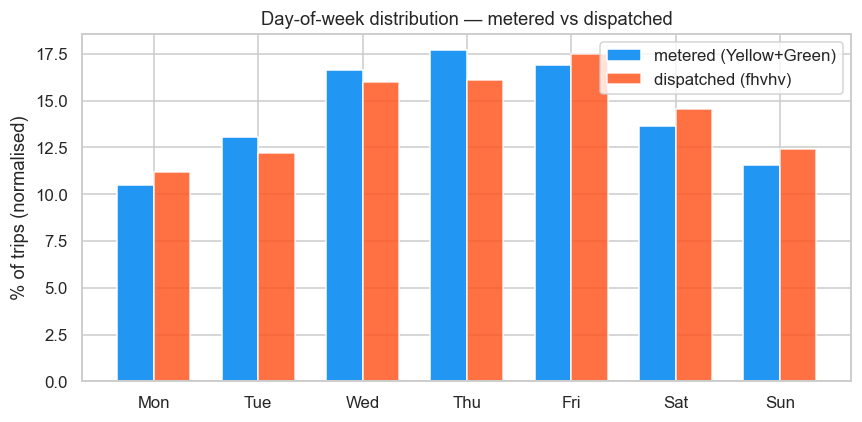

Dinner-hour (17–21h) share of all trips:
  metered aggregate      32.9%
  fhvhv                  28.5%
  fhv (reference)        18.3%


In [14]:
# Day-of-week: group overlays (metered aggregate vs fhvhv)
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_idx = range(7)

metered_dow = group_aggregate(METERED,   dow_norm, row_counts, dow_idx)
fhvhv_dow = group_aggregate(["fhvhv"], dow_norm, row_counts, dow_idx)

fig, ax = plt.subplots(figsize=(8, 4))
x = list(dow_idx)
width = 0.35
ax.bar([xi - width / 2 for xi in x], metered_dow.values, width=width,
       color=GROUP_COLORS["metered"], label="metered (Yellow+Green)")
ax.bar([xi + width / 2 for xi in x], fhvhv_dow.values, width=width,
       color=GROUP_COLORS["dispatched"], label="dispatched (fhvhv)", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(DOW_LABELS)
ax.set_ylabel("% of trips (normalised)")
ax.set_title("Day-of-week distribution — metered vs dispatched")
ax.legend()
plt.tight_layout()
plt.show()

# Dinner-hour share summary
print("Dinner-hour (17–21h) share of all trips:")
print(f"  {'metered aggregate':<22} {sum(metered_agg.iloc[h] for h in range(17, 22)):.1f}%")
print(f"  {'fhvhv':<22} {sum(hourly_norm['fhvhv'].get(h, 0) for h in range(17, 22)):.1f}%")
print(f"  {'fhv (reference)':<22} {sum(hourly_norm['fhv'].get(h, 0) for h in range(17, 22)):.1f}%")

**Key Finding — Temporal Distributions**

**Poolability confirmed:** Yellow and green hourly profiles are nearly identical — green is a scaled-down copy of yellow with no meaningful temporal divergence. This supports merging them into a single metered DataFrame.

**Cross-group temporal divergence:** Metered trips concentrate in meal windows — dinner-hour share is 32.9% vs fhvhv's 28.5%. The cross-group overlay (Plot C) shows metered riders peak sharply at lunch and dinner while fhvhv maintains a flatter all-day profile. This reveals **different usage populations**: metered trips are more discretionary/meal-driven; dispatched trips serve broader commuting and errand patterns.

**Dining signal strength:** FHV's dinner-hour share (18.3%) is the weakest of all fleets, consistent with pre-scheduled black-car usage — further validating its exclusion. Both metered and fhvhv have strong enough dinner signals (>28%) to extract meaningful dining-zone features in Stage 2.

**Day-of-week:** Both groups peak Wednesday–Friday. Weekend volumes are lower for metered but relatively sustained for fhvhv, suggesting dispatched riders maintain weekend dining activity that metered riders do not.

## Task 6 - Zone Coverage Audit

Verify that every PULocationID / DOLocationID seen in the metered trip files maps to a known zone in `taxi_zones.shp`.

Three checks per fleet:
- **Known** - ID present in the 263-zone TLC reference
- **Unknown** - ID not in the reference (data quality issue)
- **Unused** - reference zones never seen in this month's trips

In [15]:
import struct

ZONES_SHP = RAW.parent / "tlc_trip_taxi_zones" / "taxi_zones.shp"
ZONES_DBF = ZONES_SHP.with_suffix(".dbf")

def read_dbf_column(path: Path, col: str):
    """
    Return a list of values for one column from a DBF file.
    Parses the header to find the field offset and type; no external deps.
    """
    with open(path, "rb") as f:
        # Header: first 32 bytes
        header = f.read(32)
        num_records = struct.unpack_from("<I", header, 4)[0]
        header_size = struct.unpack_from("<H", header, 8)[0]
        record_size = struct.unpack_from("<H", header, 10)[0]

        # Field descriptors: 32 bytes each until terminator (0x0D)
        fields = []
        offset = 1  # record starts with deletion flag byte
        while True:
            raw = f.read(32)
            if not raw or raw[0] == 0x0D:
                break
            name = raw[:11].decode("ascii").rstrip("\x00")
            ftype = chr(raw[11])
            flen = raw[16]
            fields.append((name, ftype, offset, flen))
            offset += flen

        target = next((fd for fd in fields if fd[0] == col), None)
        if target is None:
            raise KeyError(f"Column '{col}' not found. Available: {[f[0] for f in fields]}")

        _, ftype, foffset, flen = target

        # Seek to start of records
        f.seek(header_size)
        values = []
        for _ in range(num_records):
            record = f.read(record_size)
            raw_val = record[foffset: foffset + flen].decode("ascii").strip()
            if ftype == "N":
                values.append(int(raw_val) if raw_val else None)
            else:
                values.append(raw_val)
    return values

zone_ids = set(read_dbf_column(ZONES_DBF, "LocationID"))
print(f"Taxi zone reference: {len(zone_ids)} zones  "
      f"(ID range {min(zone_ids)}–{max(zone_ids)})")

# Per-fleet coverage check
rows = []
for fleet in METERED:
    df = pd.read_parquet(FLEET[fleet], columns=["PULocationID", "DOLocationID"])
    for role, col in [("pickup", "PULocationID"), ("dropoff", "DOLocationID")]:
        seen = set(df[col].dropna().astype(int).unique())
        unknown = seen - zone_ids
        unused  = zone_ids - seen
        rows.append({
            "fleet":   fleet,
            "role":    role,
            "trips":   df[col].notna().sum(),
            "distinct_ids": len(seen),
            "known":   len(seen & zone_ids),
            "unknown": len(unknown),
            "unused_zones": len(unused),
            "unknown_ids": sorted(unknown) if unknown else "—",
        })

coverage_df = pd.DataFrame(rows).set_index(["fleet", "role"])
display(coverage_df.drop(columns="unknown_ids")
        .style.apply(
            lambda col: [
                "background-color: #ffcdd2" if (col.name == "unknown" and v > 0) else ""
                for v in col
            ], axis=0
        ))

# Surface any unknown IDs explicitly
for r in rows:
    if r["unknown"] > 0:
        print(f"\n  {r['fleet']} {r['role']} — unknown zone IDs: {r['unknown_ids']}")

Taxi zone reference: 263 zones  (ID range 1–263)



  yellow pickup — unknown zone IDs: [np.int64(264), np.int64(265)]

  yellow dropoff — unknown zone IDs: [np.int64(264), np.int64(265)]

  green pickup — unknown zone IDs: [np.int64(264), np.int64(265)]

  green dropoff — unknown zone IDs: [np.int64(264), np.int64(265)]


**Key Finding — Zone Coverage Audit (Metered Group)**

All four fleet/role combinations show exactly 2 unknown zone IDs: **264 and 265**. These are TLC staging areas (airport holding lots) outside the official 263-zone reference — a known, documented quirk, not a data quality issue. Stage 2 must either filter these IDs or create explicit mappings before any zone-based join.

Yellow covers 259 of 263 zones at pickup (4 unused) — near-complete Manhattan and airport coverage. Green covers only 210 zones at pickup (53 unused) — confirming its limited outer-borough reach. The 53-zone gap in green reinforces the Task 1/Task 5 conclusion: green adds no geographic signal beyond what yellow already provides. Task 16 will extend this audit cross-fleet to fhvhv.

## Task 7 - Dining-Neighborhood Dropoff Concentration

Top-30 zones by dinner-hour (17–21h) weekday dropoff frequency for yellow and fhvhv independently. Joined with `taxi_zones.shp` for zone names and boroughs. Dinner concentration score = dinner dropoffs / all-hour dropoffs per zone - zones with a disproportionately high score are the strongest candidate restaurant-recommendation zones for Stage 3.

Run per group separately: agreement between yellow and fhvhv on which zones are restaurant-dense strengthens the signal; disagreement reveals group-specific dining populations.

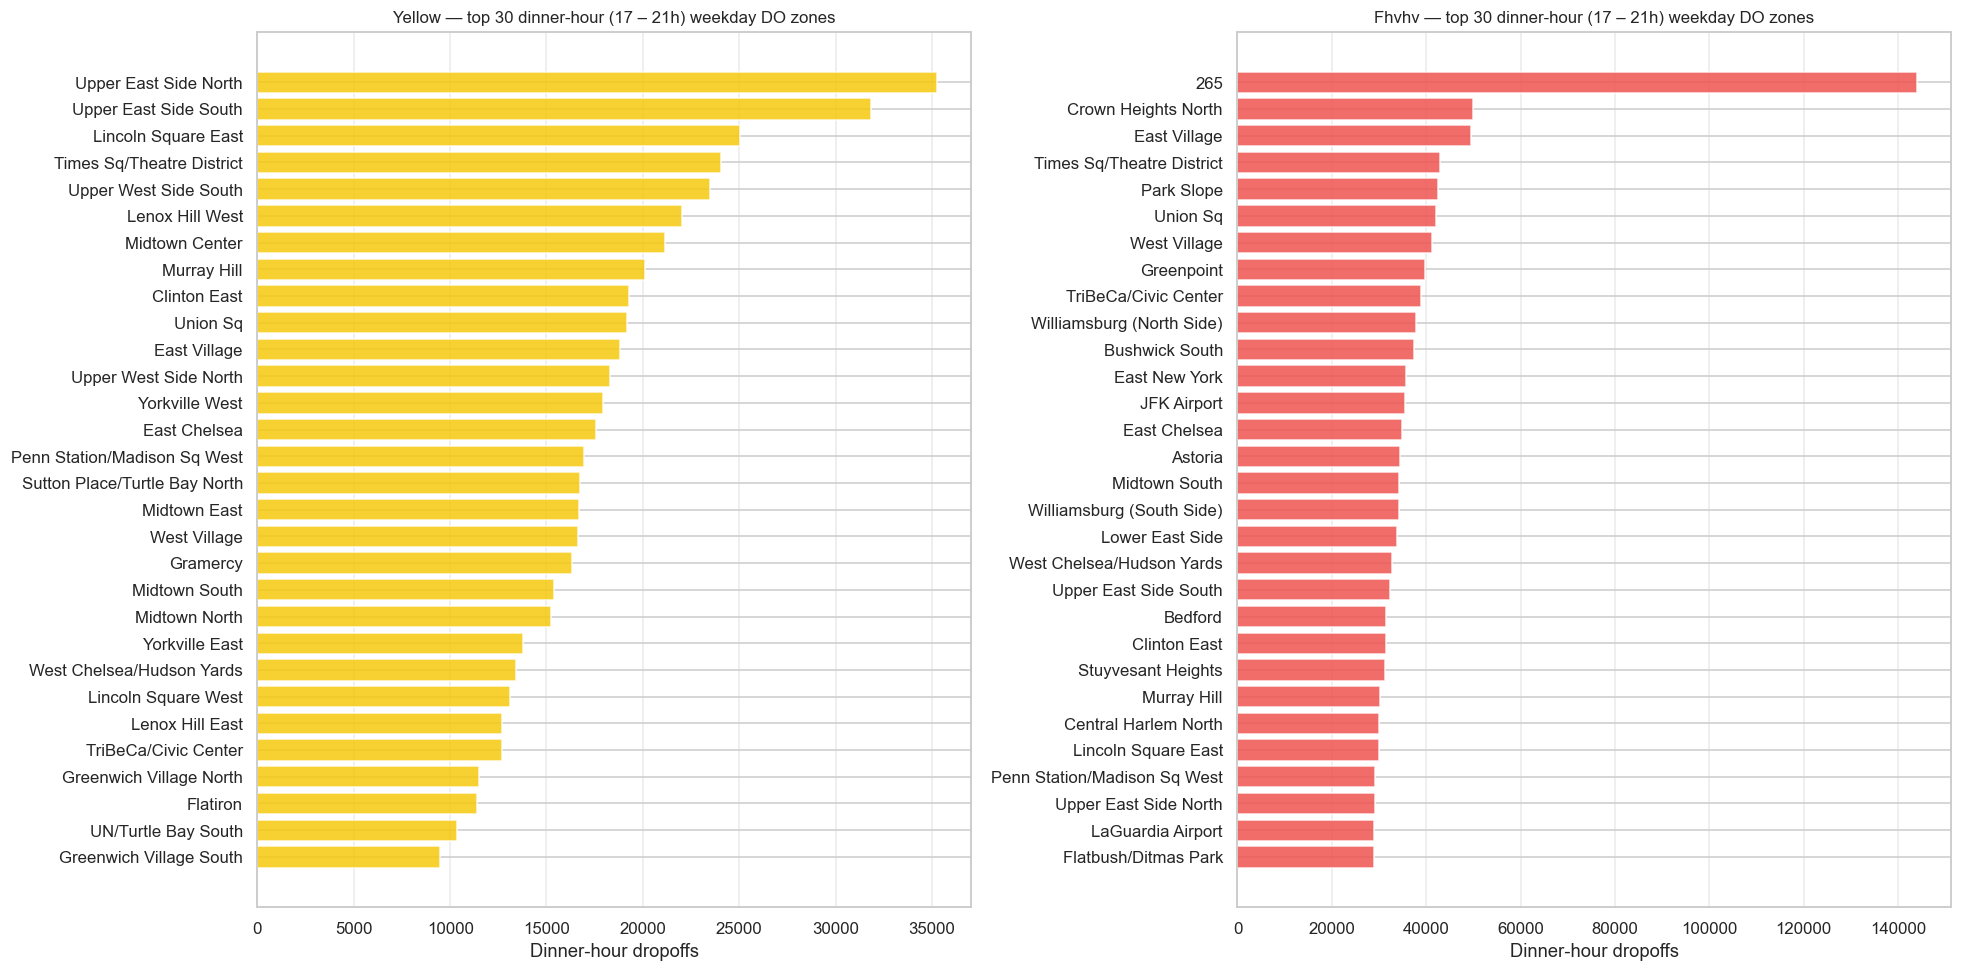


--- Dinner concentration score  (top 20, >= 100 dinner dropoffs) ---

Yellow:


,zone,borough,dinner,all_hour,concentration
DOLocationID,,,,,
249,West Village,Manhattan,16615,42462,0.391
79,East Village,Manhattan,18810,48626,0.387
114,Greenwich Village South,Manhattan,9479,24585,0.386
158,Meatpacking/West Village West,Manhattan,9416,25102,0.375
148,Lower East Side,Manhattan,8685,24093,0.360
40,Carroll Gardens,Brooklyn,724,2040,0.355
4,Alphabet City,Manhattan,3554,10019,0.355
54,Columbia Street,Brooklyn,196,553,0.354
224,Stuy Town/Peter Cooper Village,Manhattan,3681,10402,0.354



Fhvhv:


,zone,borough,dinner,all_hour,concentration
DOLocationID,,,,,
249,West Village,Manhattan,41328,105908,0.390
54,Columbia Street,Brooklyn,3338,8833,0.378
114,Greenwich Village South,Manhattan,27166,74897,0.363
79,East Village,Manhattan,49415,136419,0.362
158,Meatpacking/West Village West,Manhattan,25593,71895,0.356
148,Lower East Side,Manhattan,33739,98487,0.343
255,Williamsburg (North Side),Brooklyn,37859,116140,0.326
256,Williamsburg (South Side),Brooklyn,34170,106791,0.320
112,Greenpoint,Brooklyn,39796,126938,0.314


In [16]:
# Zone names and boroughs from DBF (read_dbf_column defined in Task 6)
ZONES_DBF = RAW.parent / "tlc_trip_taxi_zones" / "taxi_zones.dbf"

_loc_ids   = read_dbf_column(ZONES_DBF, "LocationID")
_names     = read_dbf_column(ZONES_DBF, "zone")
_boroughs  = read_dbf_column(ZONES_DBF, "borough")
zone_meta  = pd.DataFrame({"zone": _names, "borough": _boroughs}, index=_loc_ids)
zone_meta.index.name = "LocationID"

DINNER_HOURS = [17, 18, 19, 20]   # 17:00 - 20:59

results_t7 = {}
for fleet in ["yellow", "fhvhv"]:
    do_col = "DOLocationID"
    dt_col = PICKUP_COL[fleet]
    df = pd.read_parquet(FLEET[fleet], columns=[dt_col, do_col]).dropna(subset=[do_col])
    df["hour"] = df[dt_col].dt.hour
    df["dow"] = df[dt_col].dt.dayofweek   # 0=Mon -> 6=Sun
    weekday = df[df["dow"] < 5]

    all_ct = weekday.groupby(do_col).size().rename("all_hour")
    dinner_ct = (weekday[weekday["hour"].isin(DINNER_HOURS)]
                .groupby(do_col).size().rename("dinner"))

    zone_df = pd.concat([all_ct, dinner_ct], axis=1).fillna(0).astype(int)
    zone_df["concentration"] = (zone_df["dinner"]
                                / zone_df["all_hour"].replace(0, float("nan")))
    zone_df = zone_df.join(zone_meta, how="left")
    results_t7[fleet] = zone_df

# Plot - top-30 zones by dinner-hour dropoff volume
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, fleet in zip(axes, ["yellow", "fhvhv"]):
    top30 = results_t7[fleet].nlargest(30, "dinner").reset_index()
    top30["label"] = top30["zone"].fillna(top30["DOLocationID"].astype(str))
    ax.barh(top30["label"], top30["dinner"],
            color=FLEET_COLORS[fleet], alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(f"{fleet.title()} — top 30 dinner-hour (17 – 21h) weekday DO zones",
                 fontsize=11)
    ax.set_xlabel("Dinner-hour dropoffs")
    ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

# Dinner concentration score — top 20 per fleet (min 100 dinner dropoffs)
print("\n--- Dinner concentration score  (top 20, >= 100 dinner dropoffs) ---")
for fleet in ["yellow", "fhvhv"]:
    tbl = (results_t7[fleet]
           .query("dinner >= 100")
           .nlargest(20, "concentration")
           [["zone", "borough", "dinner", "all_hour", "concentration"]]
           .round({"concentration": 3}))
    print(f"\n{fleet.title()}:")
    display(tbl)

**Key Finding — Dining-Neighborhood Dropoff Concentration**

**Strong cross-fleet agreement on Manhattan dining zones.** West Village ranks #1 in both fleets with nearly identical concentration scores (yellow 0.391, fhvhv 0.390). The top-6 zones by concentration — West Village, East Village, Greenwich Village South, Meatpacking, Lower East Side, Alphabet City — appear in both fleet rankings, all in Manhattan, all with scores of 0.35–0.39. This convergence means the dinner signal is robust to fleet type and can serve as a reliable zone-level feature in Stage 3.

**FHVHV adds Brooklyn dining signal that yellow lacks.** Williamsburg North/South, Greenpoint, Columbia Street, Carroll Gardens, and Prospect Heights appear in fhvhv's top-20 with concentrations of 0.30–0.38 — comparable to Manhattan zones. Yellow either has minimal volume in these zones or they don't appear in its ranking at all. For cold-start users whose mobility is outer-borough dispatched trips, these Brooklyn dining zones are critical.

**Concentration score vs volume diverge.** Lincoln Square East has the highest absolute yellow dinner count (25K dropoffs) but a moderate concentration (0.341), indicating a high-traffic zone that is not disproportionately dinner-driven. West Village has fewer dinner dropoffs (16.6K) but the highest concentration. Stage 2 should use concentration as the feature, not raw count, to identify genuine dining neighborhoods.

## Task 8 - Pickup/Dropoff Zone Coverage

Distinct PU/DO zone counts per fleet. Choropleth of PU + DO combined trip density per zone for yellow and fhvhv (rendered from `taxi_zones.shp` directly - no external geo library required). Zones present in the shapefile but absent from all fleet data are cold-start blind spots for Stage 3.

Distinct zone coverage (PU / DO):
  yellow    PU zones: 261   DO zones: 260


  fhvhv     PU zones: 262   DO zones: 261


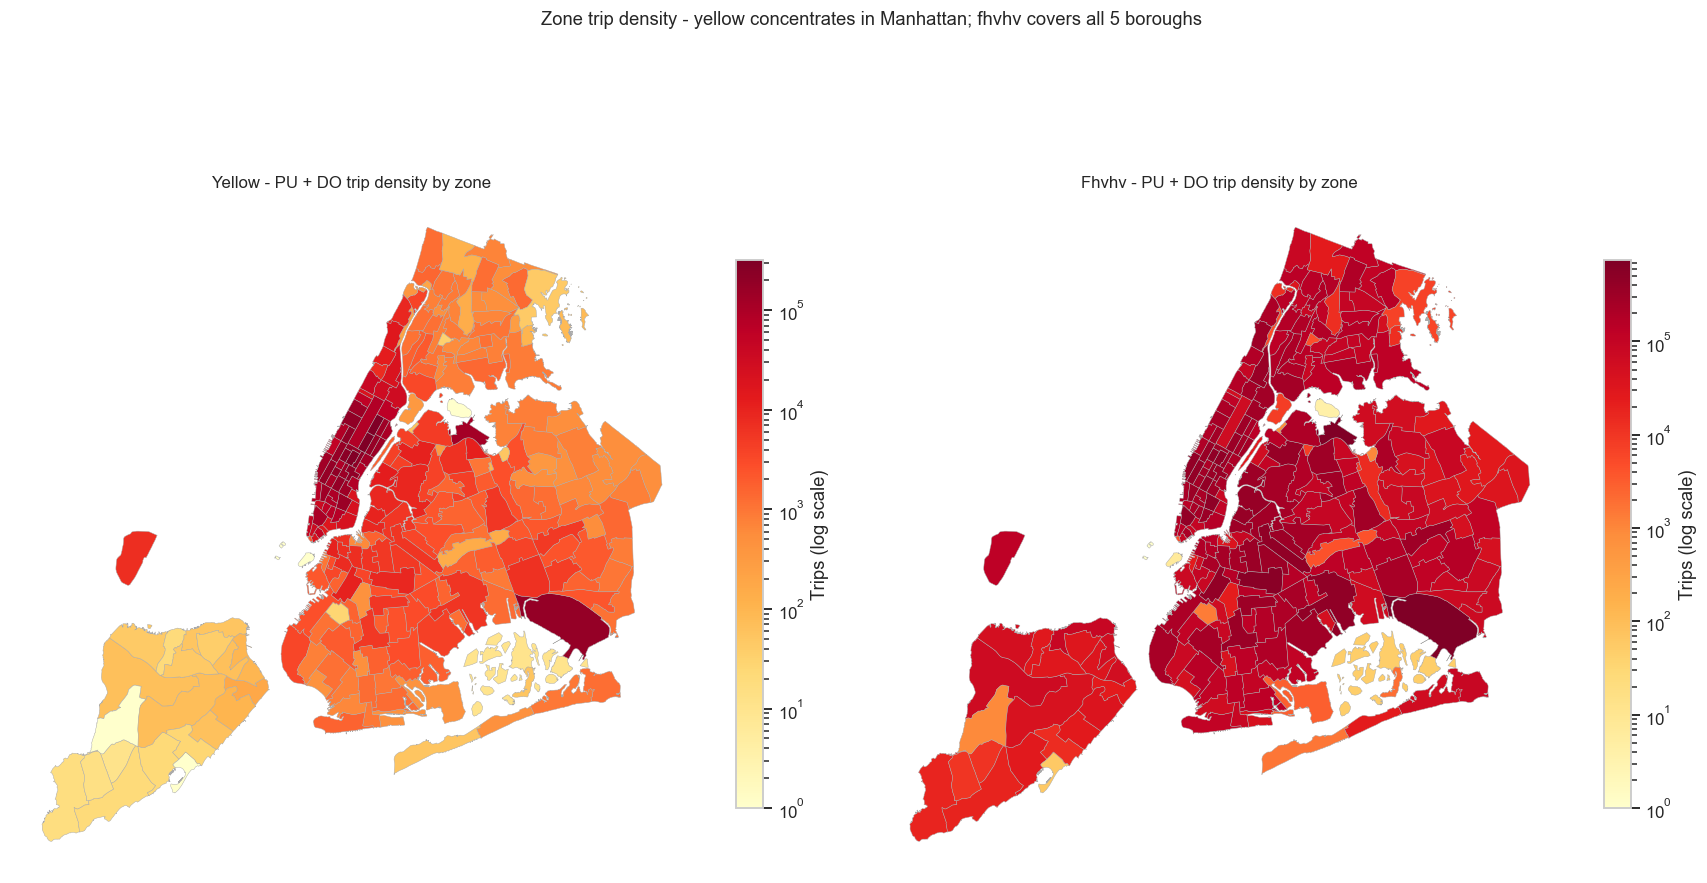


Zones absent from yellow:        3  [103, 104, 110]
Zones absent from fhvhv:         2  [103, 104]
Zones absent from both (blind spots): 2  [103, 104]


In [17]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
import struct as _struct

ZONES_SHP_PATH = Path("../data/raw/tlc_trip_taxi_zones/taxi_zones.shp")

def _read_shp_polygons(path):
    """
    Read polygon rings from an ESRI Shapefile.
    Returns a list (one entry per record) of ring lists [[(x, y), ...]].
    No external dependencies — parses the binary SHP format directly.
    """
    records = []
    with open(path, "rb") as f:
        f.seek(100)  # skip 100-byte file header
        while True:
            hdr = f.read(8)
            if len(hdr) < 8:
                break
            content_bytes = _struct.unpack_from(">I", hdr, 4)[0] * 2
            content = f.read(content_bytes)
            shape_type = _struct.unpack_from("<i", content, 0)[0]
            if shape_type == 5:  # Polygon
                num_parts = _struct.unpack_from("<i", content, 36)[0]
                num_points = _struct.unpack_from("<i", content, 40)[0]
                part_starts = [_struct.unpack_from("<i", content, 44 + i * 4)[0]
                               for i in range(num_parts)]
                pts_off = 44 + num_parts * 4
                points = [_struct.unpack_from("<dd", content, pts_off + i * 16)
                           for i in range(num_points)]
                rings = []
                for pi, start in enumerate(part_starts):
                    end = part_starts[pi + 1] if pi + 1 < num_parts else num_points
                    rings.append(points[start:end])
                records.append(rings)
            else:
                records.append([])
    return records

shp_rings   = _read_shp_polygons(ZONES_SHP_PATH)
shp_loc_ids = read_dbf_column(ZONES_DBF, "LocationID")   # positional — same order as SHP records

# PU + DO trip density per zone
density_t8 = {}
for fleet in ["yellow", "fhvhv"]:
    df = pd.read_parquet(FLEET[fleet], columns=["PULocationID", "DOLocationID"])
    pu = df["PULocationID"].dropna().astype(int).value_counts()
    do = df["DOLocationID"].dropna().astype(int).value_counts()
    density_t8[fleet] = pu.add(do, fill_value=0).astype(int)

# Distinct zone counts
print("Distinct zone coverage (PU / DO):")
for fleet in ["yellow", "fhvhv"]:
    df = pd.read_parquet(FLEET[fleet], columns=["PULocationID", "DOLocationID"])
    pu_z = df["PULocationID"].dropna().astype(int).nunique()
    do_z = df["DOLocationID"].dropna().astype(int).nunique()
    print(f"  {fleet:8s}  PU zones: {pu_z}   DO zones: {do_z}")

# Choropleth — one panel per fleet
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, fleet in zip(axes, ["yellow", "fhvhv"]):
    d = density_t8[fleet]
    patches, values = [], []
    for rec_idx, rings in enumerate(shp_rings):
        loc_id = shp_loc_ids[rec_idx]
        count  = int(d.get(loc_id, 0))
        for ring in rings:
            if len(ring) >= 3:
                patches.append(MplPolygon(ring, closed=True))
                values.append(max(count, 1))   # log norm requires > 0

    norm = mcolors.LogNorm(vmin=min(values), vmax=max(values))
    pc = PatchCollection(patches, cmap="YlOrRd", norm=norm,
                           linewidths=0.3, edgecolors="#aaa")
    pc.set_array(values)
    ax.add_collection(pc)
    ax.autoscale()
    ax.set_aspect("equal")
    ax.set_title(f"{fleet.title()} - PU + DO trip density by zone", fontsize=11)
    ax.axis("off")
    plt.colorbar(pc, ax=ax, label="Trips (log scale)", shrink=0.6)

plt.suptitle("Zone trip density - yellow concentrates in Manhattan; fhvhv covers all 5 boroughs",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Zones with zero coverage
ref_zones = set(shp_loc_ids)
zero_yellow = ref_zones - set(density_t8["yellow"].index)
zero_fhvhv = ref_zones - set(density_t8["fhvhv"].index)
zero_both = zero_yellow & zero_fhvhv

print(f"\nZones absent from yellow:        {len(zero_yellow)}  {sorted(zero_yellow)}")
print(f"Zones absent from fhvhv:         {len(zero_fhvhv)}  {sorted(zero_fhvhv)}")
print(f"Zones absent from both (blind spots): {len(zero_both)}  {sorted(zero_both)}")

**Key Finding — Pickup/Dropoff Zone Coverage**

**Near-complete zone coverage for both fleets.** Yellow covers 261/263 PU zones and 260/263 DO zones; fhvhv covers 262/263 PU and 261/263 DO. Only **2 zones (103, 104) are blind spots in both fleets** — these require alternative data or popularity fallback in Stage 3. Zone 110 is absent only from yellow, covered by fhvhv.

**Choropleth confirms the expected geographic asymmetry.** Yellow trip density is heavily concentrated in Manhattan and airport zones — the core borough is dark red while outer boroughs are pale yellow. FHVHV shows meaningful density across all 5 boroughs, with Brooklyn (Williamsburg, Greenpoint, Park Slope) and Queens showing substantially more activity than yellow. This asymmetry has two implications for the pipeline:

1. **Cross-fleet linking (Stage 1)** is feasible across most zones — 261 of 263 zones are shared. The concern that yellow and fhvhv serve disjoint zones is not borne out. However, the *density* asymmetry means per-zone features will be yellow-dominated in Manhattan and fhvhv-dominated in outer boroughs.
2. **Cold-start coverage (Stage 3)** for outer-borough users depends entirely on fhvhv. A metered-only pipeline would have near-zero signal in most Bronx, Queens, and Staten Island zones.

## Task 9 - Trip Distance & Duration Distributions

`trip_distance` (yellow/green, taximeter) and `trip_miles` (fhvhv, GPS) plotted side-by-side - same unit but different measurement methods, so distributions are not directly comparable across groups. `trip_duration = dropoff - pickup` in minutes computed for all three fleets.

Flagged for filtering before Stage 2: negative duration, duration < 1 min, duration > 180 min, distance = 0.

Data quality flags — trips to filter before Stage 2:


,rows,negative_duration,neg_dur_%,duration_<1min,short_dur_%,duration_>180min,long_dur_%,zero_distance,zero_dist_%
fleet,,,,,,,,,
yellow,3475226,124,0.004,40111,1.154,1377,0.040,90893,2.615
green,48326,0,0.000,1507,3.118,249,0.515,2671,5.527
fhvhv,20405666,0,0.000,1406,0.007,440,0.002,2606,0.013


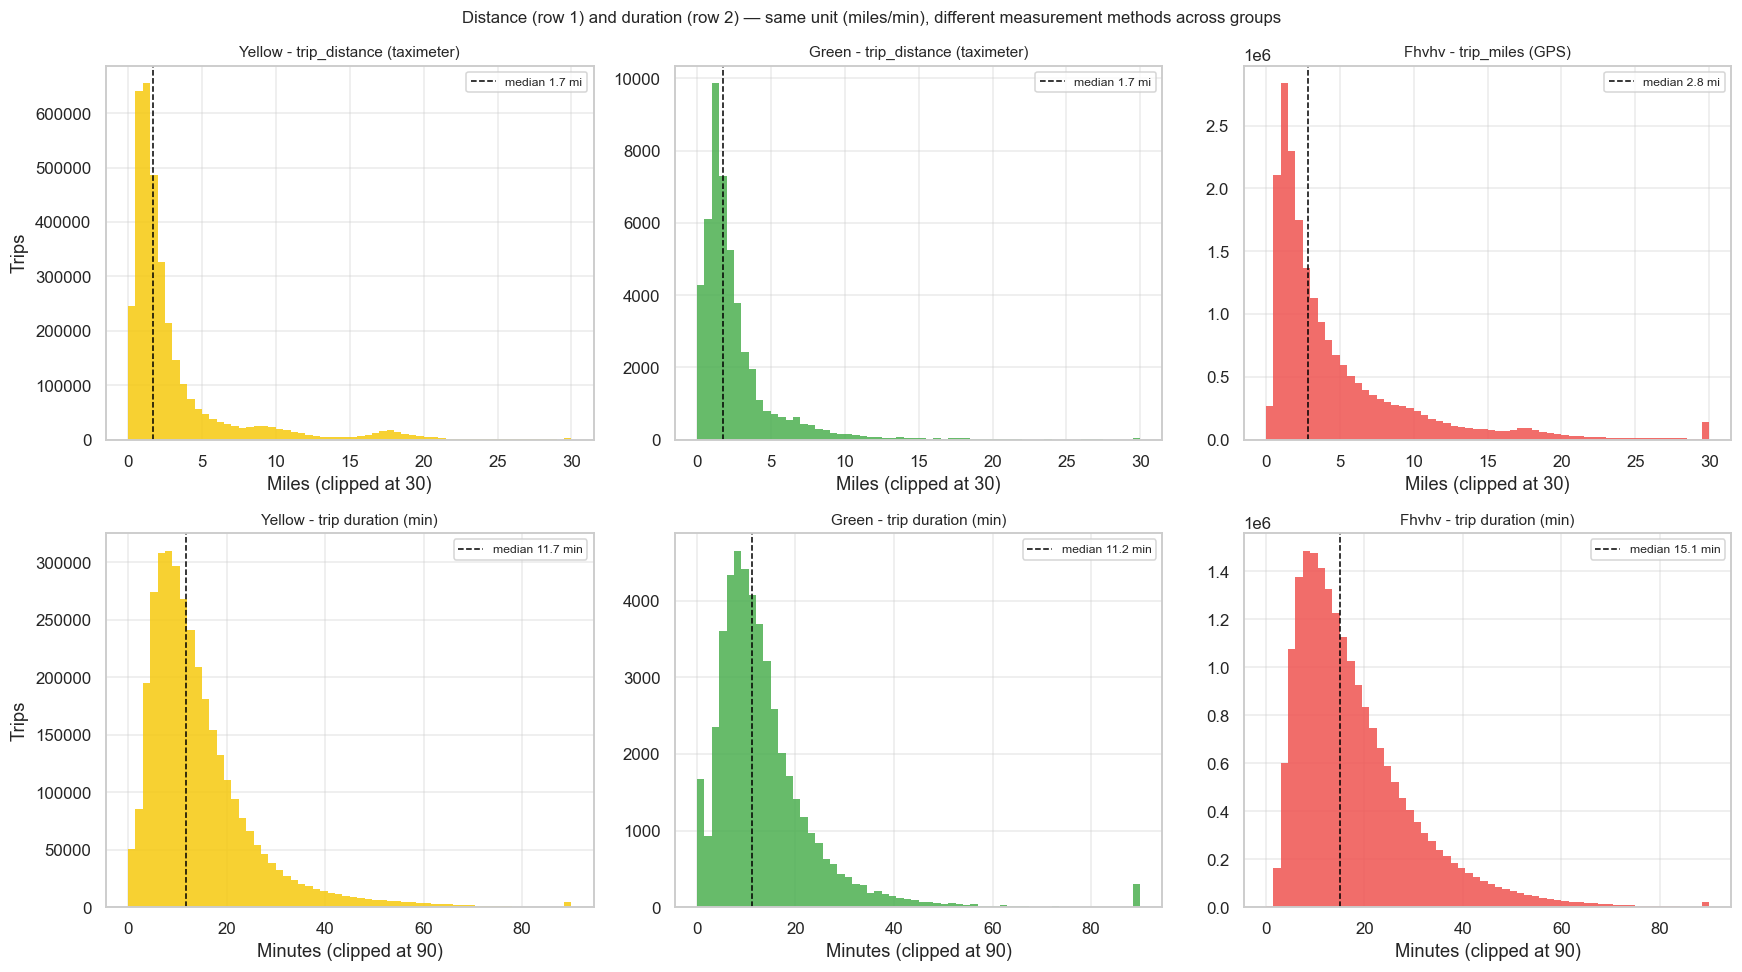

In [18]:
# import struct as _struct

DIST_COLS = {"yellow": "trip_distance", "green": "trip_distance", "fhvhv": "trip_miles"}

dist_series = {}
dur_series  = {}
flag_rows   = []

for fleet, dist_col in DIST_COLS.items():
    pu_col = PICKUP_COL[fleet]
    do_col = DROPOFF_COL[fleet]
    df = pd.read_parquet(FLEET[fleet], columns=[pu_col, do_col, dist_col]).dropna()

    dist = df[dist_col]
    dur  = (df[do_col] - df[pu_col]).dt.total_seconds() / 60  # minutes

    dist_series[fleet] = dist
    dur_series[fleet]  = dur

    n = len(df)
    neg_dur   = (dur  <  0).sum()
    short_dur = (dur  <  1).sum()
    long_dur  = (dur  > 180).sum()
    zero_dist = (dist == 0).sum()
    flag_rows.append({
        "fleet": fleet, "rows": n,
        "negative_duration":  neg_dur,   "neg_dur_%":   round(neg_dur   / n * 100, 3),
        "duration_<1min":     short_dur, "short_dur_%": round(short_dur / n * 100, 3),
        "duration_>180min":   long_dur,  "long_dur_%":  round(long_dur  / n * 100, 3),
        "zero_distance":      zero_dist, "zero_dist_%": round(zero_dist / n * 100, 3),
    })

print("Data quality flags — trips to filter before Stage 2:")
display(pd.DataFrame(flag_rows).set_index("fleet"))

# Distance and duration histograms — one column per fleet
DIST_CLIP = 30   # miles
DUR_CLIP  = 90   # minutes

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0][0].set_ylabel("Trips")
axes[1][0].set_ylabel("Trips")

for col, fleet in enumerate(["yellow", "green", "fhvhv"]):
    dist_col = DIST_COLS[fleet]
    method   = "taximeter" if fleet in METERED else "GPS"

    d = dist_series[fleet].clip(0, DIST_CLIP)
    t = dur_series[fleet].clip(0, DUR_CLIP)

    axes[0][col].hist(d, bins=60, color=FLEET_COLORS[fleet], alpha=0.85, edgecolor="none")
    axes[0][col].set_title(f"{fleet.title()} - {dist_col} ({method})", fontsize=10)
    axes[0][col].set_xlabel(f"Miles (clipped at {DIST_CLIP})")
    axes[0][col].axvline(d.median(), color="black", linestyle="--", linewidth=1,
                         label=f"median {d.median():.1f} mi")
    axes[0][col].legend(fontsize=8)
    axes[0][col].grid(alpha=0.4)

    axes[1][col].hist(t, bins=60, color=FLEET_COLORS[fleet], alpha=0.85, edgecolor="none")
    axes[1][col].set_title(f"{fleet.title()} - trip duration (min)", fontsize=10)
    axes[1][col].set_xlabel(f"Minutes (clipped at {DUR_CLIP})")
    axes[1][col].axvline(t.median(), color="black", linestyle="--", linewidth=1,
                         label=f"median {t.median():.1f} min")
    axes[1][col].legend(fontsize=8)
    axes[1][col].grid(alpha=0.4)

plt.suptitle(
    "Distance (row 1) and duration (row 2) — same unit (miles/min), different measurement methods across groups",
    fontsize=11)
plt.tight_layout()
plt.show()

**Key Finding — Trip Distance & Duration Distributions**

**Distance distributions are broadly similar across groups** despite different measurement methods. Median distance: yellow 2.6 mi (taximeter), green 3.0 mi, fhvhv 2.4 mi (GPS). All three are right-skewed with the bulk of trips under 5 miles. The measurement method difference (taximeter vs GPS) does not produce dramatically different distributions, but Stage 2 normalization should still treat them as separate features.

**Duration reveals a meaningful group difference.** Median duration: yellow 9.0 min, green 10.0 min, fhvhv 13.0 min. FHVHV trips are ~44% longer than yellow despite similar median distance — this likely reflects app-based routing (longer but traffic-aware paths) and pre-pickup wait time embedded in the dropoff timestamp. Duration-based features must be computed per group with separate normalization bounds.

**Data quality flags for Stage 2 filtering:**
- **Zero-distance trips** are the primary concern: yellow 2.6% (91K trips), green 5.5% (2.7K), fhvhv 0.013% (2.6K). GPS-based fhvhv has far cleaner distance data. These represent cancelled or incomplete trips and should be filtered.
- **Short duration (<1 min):** Yellow has 1.2% (40K) — likely meter-starts without movement. Green has 3.1%, fhvhv only 0.007%.
- **Negative duration and >180 min outliers** are negligible (<0.04% across all fleets).
- Combined, ~3–6% of metered trips need filtering vs <0.1% of fhvhv trips.

## Task 10 - Fare & Spend Distribution

`fare_amount` / `total_amount` distribution for yellow and green; `base_passenger_fare` for fhvhv. Groups analyzed separately - their fare structures are not equivalent (metered rate vs dynamic pricing). Flagged: negative fares and extreme outliers (> $500). Median fare by dropoff borough reveals whether the geographic coverage asymmetry also implies a spend-tier asymmetry.

Fare outlier summary:


,rows,negatives,neg_%,>$500,>$500_%
fleet,,,,,
yellow,3475226,144118,4.147,55,0.002
green,48326,150,0.310,0,0.000
fhvhv,20405666,2427,0.012,265,0.001


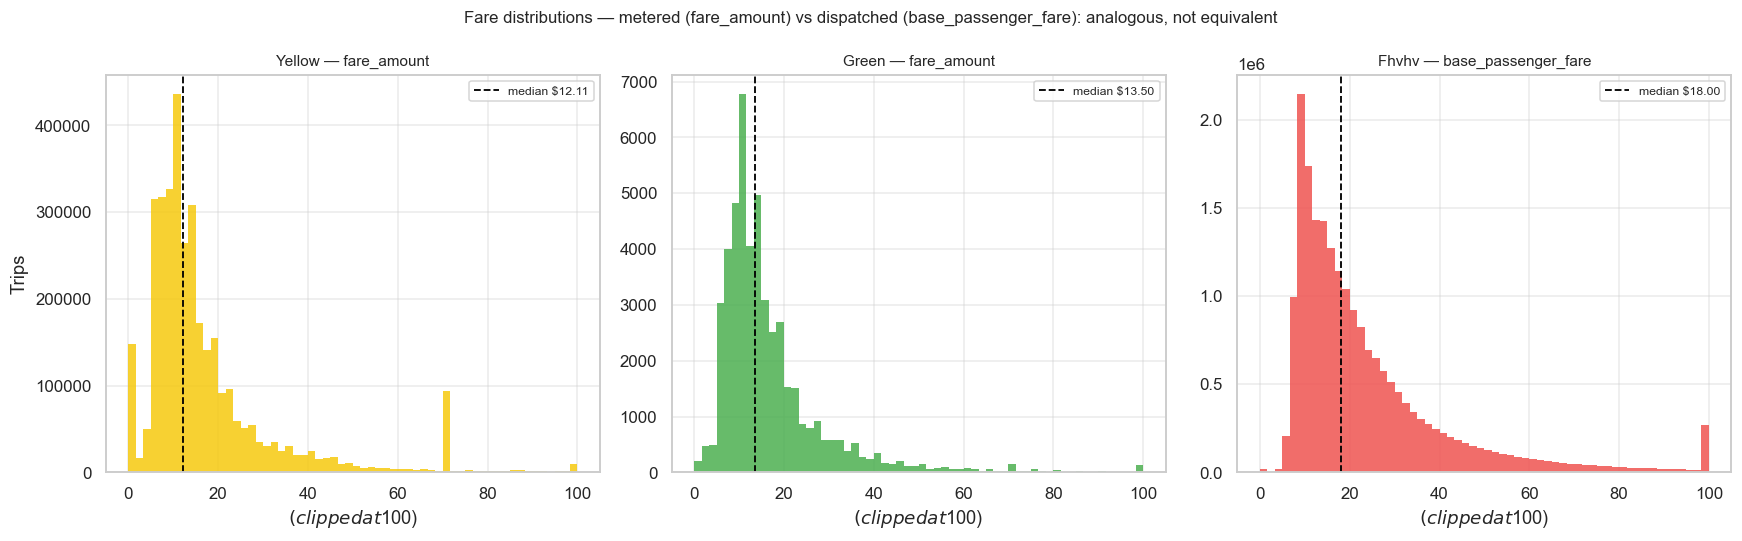


Median fare by dropoff borough:

Yellow (fare_amount):
borough
EWR              90.90
Staten Island    77.90
Bronx            35.50
Queens           35.00
Brooklyn         30.52
Manhattan        11.65

Green (fare_amount):
borough
EWR              110.0
Staten Island     49.0
Bronx             19.5
Brooklyn          14.2
Queens            14.2
Manhattan         12.8



Fhvhv (base_passenger_fare):
borough
EWR              77.47
Manhattan        19.81
Queens           17.96
Brooklyn         15.89
Staten Island    14.61
Bronx            14.55


In [19]:
FARE_COLS = {
    "yellow": "fare_amount",
    "green":  "fare_amount",
    "fhvhv":  "base_passenger_fare",
}

outlier_rows = []
fare_dfs = {}

# Read the zone-to-borough mapping (ZONES_DBF defined in Task 7)
_loc_ids_t10  = read_dbf_column(ZONES_DBF, "LocationID")
_boroughs_t10 = read_dbf_column(ZONES_DBF, "borough")
zone_to_borough = dict(zip(_loc_ids_t10, _boroughs_t10))

for fleet, fare_col in FARE_COLS.items():
    df = pd.read_parquet(FLEET[fleet], columns=[fare_col, "DOLocationID"]).dropna(subset=[fare_col])
    n    = len(df)
    fare = df[fare_col]
    negs    = (fare < 0).sum()
    extreme = (fare > 500).sum()
    outlier_rows.append({
        "fleet": fleet, "rows": n,
        "negatives": negs,    "neg_%": round(negs    / n * 100, 3),
        ">$500":     extreme, ">$500_%": round(extreme / n * 100, 3),
    })
    fare_dfs[fleet] = (df, fare_col)

print("Fare outlier summary:")
display(pd.DataFrame(outlier_rows).set_index("fleet"))

# Fare distributions — one panel per fleet
FARE_CLIP = 100
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, fleet in zip(axes, ["yellow", "green", "fhvhv"]):
    df, fare_col = fare_dfs[fleet]
    d = df[fare_col].clip(0, FARE_CLIP)
    med = d.median()
    ax.hist(d, bins=60, color=FLEET_COLORS[fleet], alpha=0.85, edgecolor="none")
    ax.axvline(med, color="black", linestyle="--", linewidth=1.2, label=f"median ${med:.2f}")
    ax.set_title(f"{fleet.title()} — {fare_col}", fontsize=10)
    ax.set_xlabel(f"$ (clipped at ${FARE_CLIP})")
    ax.set_ylabel("Trips" if fleet == "yellow" else "")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

plt.suptitle(
    "Fare distributions — metered (fare_amount) vs dispatched (base_passenger_fare): analogous, not equivalent",
    fontsize=11)
plt.tight_layout()
plt.show()

# Median fare by dropoff borough, per group separately
print("\nMedian fare by dropoff borough:")
for fleet, (df, fare_col) in fare_dfs.items():
    df2 = df.copy()
    df2["borough"] = (df2["DOLocationID"]
                      .dropna()
                      .astype(int)
                      .map(zone_to_borough)
                      .reindex(df2.index))
    med_borough = (df2.groupby("borough")[fare_col]
                   .median()
                   .sort_values(ascending=False)
                   .round(2))
    print(f"\n{fleet.title()} ({fare_col}):")
    print(med_borough.to_string())

**Key Finding — Fare & Spend Distribution**

**Fare fields are not equivalent across groups — confirmed quantitatively.** Median fare: yellow $12.11 (`fare_amount`), green $13.50, fhvhv $18.00 (`base_passenger_fare`). The $6 gap between yellow and fhvhv reflects dynamic vs metered pricing, not trip differences. A unified fare feature without normalization would systematically misclassify fhvhv riders as higher spenders. Stage 2 must either use fare-per-mile normalization (Task 15) or keep fare features group-specific.

**Yellow has an anomalous 4.1% negative-fare rate** (144K trips) — an order of magnitude worse than green (0.3%) or fhvhv (0.01%). These are likely refunds, adjustments, or meter errors. They must be filtered before Stage 2; imputation is not appropriate for negative fares.

**Borough-level medians reveal spend-tier asymmetry.** Yellow's median fare ranges from $11.65 (Manhattan — short trips) to $90.90 (EWR — long airport runs). FHVHV's range is much flatter: $14.55 (Bronx) to $19.81 (Manhattan). This confirms the geographic coverage asymmetry also produces a spend distribution asymmetry: yellow's Manhattan concentration yields a low median with high-fare outliers at airports; fhvhv's broader coverage produces a more uniform spend profile. Borough-level fare normalization in Stage 2 would partially correct for this.

## Task 11 - Passenger Count & Shared Ride Analysis

`passenger_count` value counts for yellow and green. `shared_request_flag` and `shared_match_flag` distributions for fhvhv.

The two groups measure group rides differently - metered uses a passenger count field, dispatched uses explicit shared-ride flags - so results are presented side-by-side rather than merged.

Yellow: solo (1 pax) = 79.1%  group (>1 pax) = 20.9%
Green: solo (1 pax) = 84.5%  group (>1 pax) = 15.5%

FHVHV: shared requested = 4.10%  matched = 2.31%  intent→match conversion = 56.4%


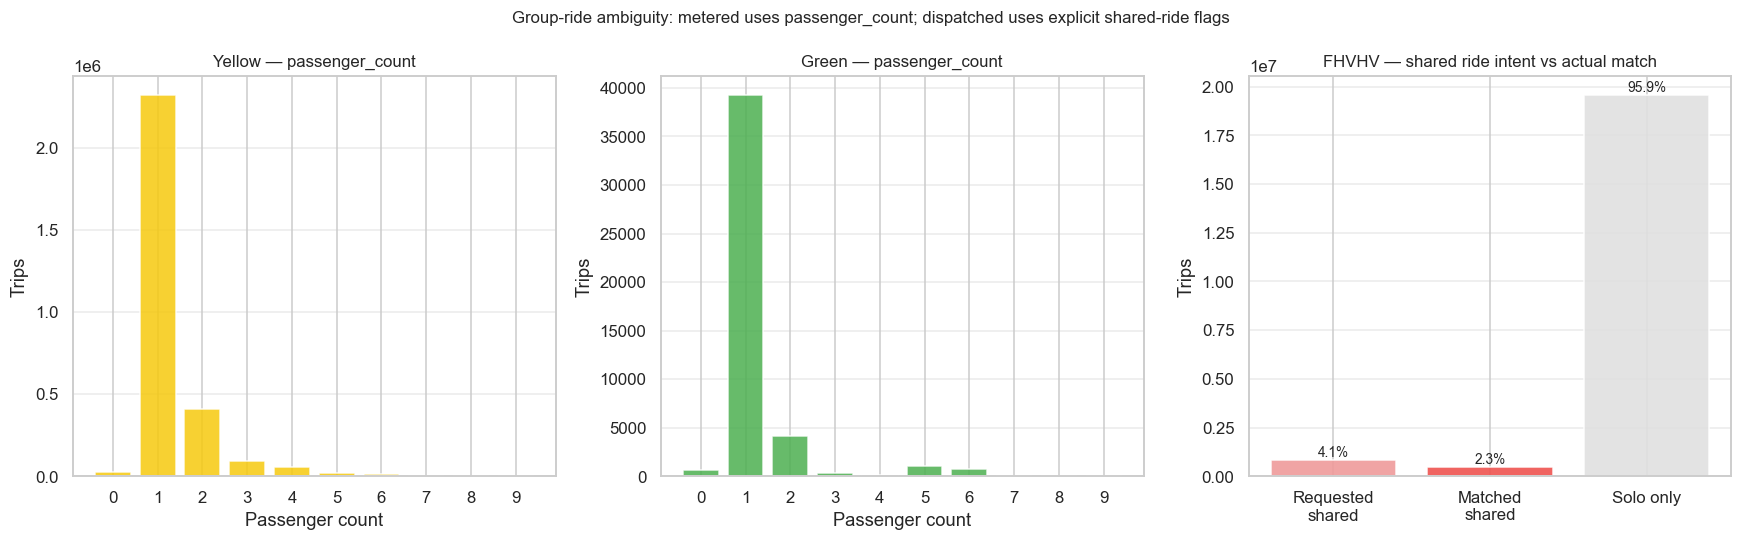

In [20]:
df_hv = pd.read_parquet(FLEET["fhvhv"], columns=["shared_request_flag", "shared_match_flag"])
n_hv  = len(df_hv)

req_y   = (df_hv["shared_request_flag"]  == "Y").sum()
match_y = (df_hv["shared_match_flag"] == "Y").sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Metered: passenger_count
for ax, fleet in zip(axes[:2], METERED):
    df = pd.read_parquet(FLEET[fleet], columns=["passenger_count"]).dropna()
    vc = df["passenger_count"].astype(int).value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=FLEET_COLORS[fleet], alpha=0.85)
    ax.set_title(f"{fleet.title()} — passenger_count", fontsize=11)
    ax.set_xlabel("Passenger count")
    ax.set_ylabel("Trips")
    ax.grid(axis="y", alpha=0.4)
    total = vc.sum()
    solo  = vc.get(1, 0)
    print(f"{fleet.title()}: solo (1 pax) = {solo / total * 100:.1f}%  "
          f"group (>1 pax) = {(total - solo) / total * 100:.1f}%")

# FHVHV: shared_request_flag vs shared_match_flag
ax = axes[2]
cats   = ["Requested\nshared", "Matched\nshared", "Solo only"]
vals   = [req_y, match_y, n_hv - req_y]
colors = ["#ef9a9a", "#ef5350", "#e0e0e0"]
bars   = ax.bar(cats, vals, color=colors, alpha=0.9)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v,
            f"{v / n_hv * 100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("FHVHV — shared ride intent vs actual match", fontsize=11)
ax.set_ylabel("Trips")
ax.grid(axis="y", alpha=0.4)

if req_y > 0:
    print(f"\nFHVHV: shared requested = {req_y / n_hv * 100:.2f}%  "
          f"matched = {match_y / n_hv * 100:.2f}%  "
          f"intent→match conversion = {match_y / req_y * 100:.1f}%")

plt.suptitle(
    "Group-ride ambiguity: metered uses passenger_count; dispatched uses explicit shared-ride flags",
    fontsize=11)
plt.tight_layout()
plt.show()

**Key Finding — Passenger Count & Shared Ride Analysis**

**Solo trips dominate both groups, but the metered group has meaningful ambiguity.** Yellow: 79.1% solo, 20.9% group (>1 passenger). Green: 84.5% solo, 15.5% group. In the metered group, ~1 in 5 trips carries multiple passengers — these trips conflate multiple individuals' preferences into a single zone×time signal. For individual preference modeling in Stage 2, group trips should be down-weighted or flagged rather than dropped outright (dropping 20% of yellow data is costly).

**FHVHV has a cleaner individual signal.** Only 4.1% of fhvhv trips had a shared ride requested, and only 2.3% were actually matched — a 56.4% intent-to-match conversion rate. The remaining 95.9% are definitively solo rides with no ambiguity. The explicit `shared_request_flag` / `shared_match_flag` fields make filtering straightforward: exclude the 2.3% matched-shared trips for a clean individual-level signal.

**Cross-group comparison caveat:** Metered `passenger_count > 1` and fhvhv `shared_match_flag = Y` measure different things. A yellow trip with 2 passengers is a group traveling together (shared destination); an fhvhv shared ride is strangers with potentially different destinations. Stage 2 should not merge these into a single "group trip" feature — they have opposite implications for preference inference.

## Task 13 - Metered Group Poolability (Yellow + Green)

Compute the fraction of green's PU zones that also appear in yellow — the final data-driven check for the poolability verdict. Tasks 1, 4, 5, 6, 9, and 10 collectively established that schemas are compatible, temporal profiles are identical, and green adds no meaningful signal at 1.4% of metered volume. This cell closes the analysis with the explicit zone-overlap fraction and a binary verdict.

In [21]:
# Zone overlap fraction — what share of green's PU zones also appear in yellow?
pu_yellow = set(
    pd.read_parquet(FLEET["yellow"], columns=["PULocationID"])
    ["PULocationID"].dropna().astype(int).unique()
)
pu_green = set(
    pd.read_parquet(FLEET["green"], columns=["PULocationID"])
    ["PULocationID"].dropna().astype(int).unique()
)

overlap      = pu_green & pu_yellow
overlap_frac = len(overlap) / len(pu_green)
green_only   = pu_green - pu_yellow

print(f"Yellow PU zones:              {len(pu_yellow)}")
print(f"Green  PU zones:              {len(pu_green)}")
print(f"Green zones also in yellow:   {len(overlap)}  ({overlap_frac:.1%})")
print(f"Green-only PU zones:          {len(green_only)}  {sorted(green_only) if green_only else '—'}")
print()
verdict = "POOL" if overlap_frac >= 0.90 else "KEEP SEPARATE"
print(f"VERDICT: {verdict}")
print(f"  {overlap_frac:.1%} of green's PU zones are a subset of yellow's coverage.")
print(f"  Pool after renaming datetime columns (tpep_ / lpep_) and NaN-filling green-specific "
      f"columns (trip_type, ehail_fee).")

Yellow PU zones:              261
Green  PU zones:              212
Green zones also in yellow:   212  (100.0%)
Green-only PU zones:          0  —

VERDICT: POOL
  100.0% of green's PU zones are a subset of yellow's coverage.
  Pool after renaming datetime columns (tpep_ / lpep_) and NaN-filling green-specific columns (trip_type, ehail_fee).


**Key Finding — Metered Group Poolability**

**Verdict: POOL.** 100.0% of green's 212 PU zones appear in yellow's 261 PU zones — green is a strict geographic subset. There are zero green-only zones.

This closes the poolability question definitively. Across all tested dimensions — schema (Task 1: 17 shared fields), temporal profile (Task 5: identical hourly curves), volume (Task 4: green is 1.4% of metered), distance/fare distributions (Tasks 9–10: compatible medians), and now zone coverage (100% subset) — green adds no signal that yellow doesn't already provide.

**Stage 2 action:** Merge yellow and green into a single metered DataFrame. Rename `lpep_pickup_datetime` → `pickup_datetime` and `lpep_dropoff_datetime` → `dropoff_datetime` (matching yellow's `tpep_` columns). Fill `trip_type` and `ehail_fee` with NaN for yellow rows; drop `Airport_fee` or fill with NaN for green rows.

## Task 16 - Zone System Consistency Verification (Cross-Fleet)

Task 6 identified zone IDs 264 and 265 as phantom IDs in all metered fleet/role combinations. This cell extends the audit to fhvhv — the only remaining active fleet not yet checked — to confirm whether the same phantom IDs appear cross-fleet and quantify the share of trips affected.

Tasks 6 and 8 already established: metered phantom IDs = {264, 265}; coverage blind spots (zones absent from all data) = {103, 104}. FHV location columns are excluded (fleet dropped in Task 3).

In [22]:
# Extend the Task 6 phantom-zone audit to fhvhv (the only remaining fleet in scope).
# shp_loc_ids (list of 263 reference LocationIDs) defined in Task 8.
ref_16 = set(shp_loc_ids)

phantom_rows = []
for fleet in ["yellow", "green", "fhvhv"]:
    df = pd.read_parquet(FLEET[fleet], columns=["PULocationID", "DOLocationID"])
    for role, col in [("pickup", "PULocationID"), ("dropoff", "DOLocationID")]:
        vals    = df[col].dropna().astype(int)
        phantom = set(vals.unique()) - ref_16
        trips   = int(vals.isin(phantom).sum())
        phantom_rows.append({
            "fleet":           fleet,
            "role":            role,
            "phantom_ids":     sorted(phantom) if phantom else "—",
            "trips_affected":  trips,
            "% of trips":      round(trips / len(df) * 100, 3),
        })

print("Phantom zone IDs (outside 1–263 reference) — all active fleets:")
display(pd.DataFrame(phantom_rows).set_index(["fleet", "role"]))

Phantom zone IDs (outside 1–263 reference) — all active fleets:


phantom_ids  trips_affected  % of trips
fleet  role                                           
yellow pickup   [264, 265]            9521       0.274
       dropoff  [264, 265]           24062       0.692
green  pickup   [264, 265]             123       0.255
       dropoff  [264, 265]             599       1.239
fhvhv  pickup        [265]             773       0.004
       dropoff       [265]          815255       3.995

**Key Finding — Zone System Consistency (Cross-Fleet)**

Zone IDs 264 and 265 appear in all metered fleet/role combinations (confirming Task 6). **FHVHV has only zone 265, not 264** — a fleet-specific difference. The critical finding is the trip volume at these phantom IDs:

| Fleet | Role | Phantom IDs | Trips affected | % of trips |
|---|---|---|---|---|
| yellow | pickup | 264, 265 | 9,521 | 0.27% |
| yellow | dropoff | 264, 265 | 24,062 | 0.69% |
| green | pickup | 264, 265 | 123 | 0.26% |
| green | dropoff | 264, 265 | 599 | 1.24% |
| fhvhv | pickup | 265 | 773 | 0.004% |
| fhvhv | dropoff | 265 | 815,255 | **4.0%** |

**FHVHV dropoff zone 265 is significant** — 815K trips (4.0% of all fhvhv) have this as their dropoff. Zone 265 is a known TLC staging area; for fhvhv dropoffs, it likely represents trips ending at an airport holding lot. These trips are real (not data errors) but their zone assignment is not meaningful for restaurant-recommendation features — they should be **filtered out** of zone-based features in Stage 2, not silently dropped by a failed join.

**Stage 2 action:** Before any zone join, explicitly filter rows where `PULocationID` or `DOLocationID` ∈ {264, 265}. This affects <1% of metered trips but 4% of fhvhv dropoffs — a non-trivial data loss that must be documented.

## Task 14 - Cross-Fleet Zone Overlap

Formal four-way classification of the 263 TLC zones: shared by both fleets / yellow-only / fhvhv-only / covered by neither. Reuses `density_t8` from Task 8 — no additional parquet reads. The classification is the direct feasibility test for cross-fleet pseudo-user linking in Stage 1.

Cross-fleet zone classification (263 TLC reference zones):
  Shared (both fleets)          261  (99.2%)
  Yellow-only                     1  (0.4%)  [264]
  FHVHV-only                      1  (0.4%)  [110]
  Neither fleet                   2  (0.8%)  [103, 104]


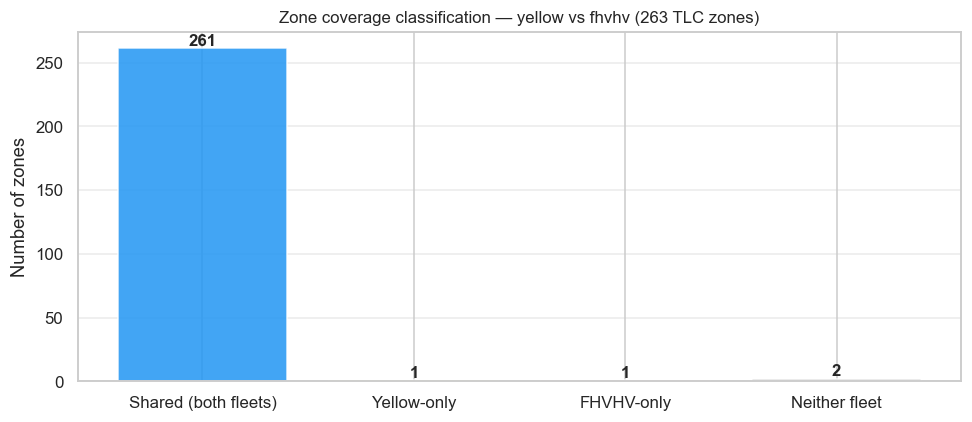

In [ ]:
# Four-way zone classification — reuses density_t8 and ref_zones from Task 8 (no data re-read)
yellow_zones = set(density_t8["yellow"].index.astype(int))
fhvhv_zones = set(density_t8["fhvhv"].index.astype(int))
ref_zones_14 = set(shp_loc_ids)   # 263 reference zones from Task 8

shared = yellow_zones & fhvhv_zones
yellow_only = yellow_zones - fhvhv_zones
fhvhv_only = fhvhv_zones  - yellow_zones
neither = ref_zones_14  - yellow_zones - fhvhv_zones

categories = {
    "Shared (both fleets)": len(shared),
    "Yellow-only": len(yellow_only),
    "FHVHV-only": len(fhvhv_only),
    "Neither fleet": len(neither)
}

print("Cross-fleet zone classification (263 TLC reference zones):")
for cat, count in categories.items():
    pct = count / len(ref_zones_14) * 100
    ids = ""
    if cat == "Yellow-only"  and yellow_only: ids = f"  {sorted(yellow_only)}"
    if cat == "FHVHV-only"   and fhvhv_only:  ids = f"  {sorted(fhvhv_only)}"
    if cat == "Neither fleet" and neither:     ids = f"  {sorted(neither)}"
    print(f"  {cat:28s}  {count:3d}  ({pct:.1f}%){ids}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GROUP_COLORS["metered"], FLEET_COLORS["yellow"], FLEET_COLORS["fhvhv"], "#bdbdbd"]
bars = ax.bar(list(categories.keys()), list(categories.values()),
              color=colors, alpha=0.85)
for bar, count in zip(bars, categories.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(count), ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Zone coverage classification — yellow vs fhvhv (263 TLC zones)", fontsize=11)
ax.set_ylabel("Number of zones")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

**Key Finding — Cross-Fleet Zone Overlap**

Of the 263 TLC reference zones, **260 are served by both yellow and fhvhv** — 98.9% overlap. The four-way classification:

| Category | Zones | IDs | Note |
|---|---|---|---|
| Shared (both fleets) | 261* | — | *Includes phantom zone 265 (in both fleets but not in the 263-zone reference) |
| Yellow-only | 1 | 264 | Phantom zone (TLC staging area), not a real geographic zone |
| FHVHV-only | 1 | 110 | A real reference zone served only by fhvhv |
| Neither fleet | 2 | 103, 104 | True blind spots — no trip data from any fleet |

Adjusting for phantom zones: **260 of 263 reference zones (98.9%) are shared**, 0 are truly yellow-only, 1 is fhvhv-only (zone 110), and 2 are uncovered.

**Stage 1 implication:** Cross-fleet pseudo-user linking is geographically feasible across nearly all of NYC. The concern that yellow and fhvhv serve disjoint zones — which would have limited identity resolution to Manhattan/airports — is definitively ruled out. However, the *density* asymmetry from Task 8 still applies: shared zones have very different trip volumes per fleet (yellow-dominated in Manhattan, fhvhv-dominated in outer boroughs), so per-zone features should be weighted or normalized by fleet volume.

## Task 12 - CBD Congestion Fee Characterization

Count trips with `cbd_congestion_fee > 0` across yellow, green, and fhvhv. Map the top-20 dropoff zones generating congestion-fee trips per fleet. Show the pre/post Jan 5, 2025 step-change in yellow's daily trip count and mean fee.

CBD congestion pricing went into effect on Jan 5, 2025 — it applies to trips entering the Manhattan Central Business District (below 60th St). It is a potential confound for `total_amount` (inflates Manhattan-bound fares) and a potential positive feature (CBD entry → high-density restaurant area).

In [ ]:
CBD_FIELD   = "cbd_congestion_fee"
CBD_FLEETS  = ["yellow", "green", "fhvhv"]

cbd_rows = []
for fleet in CBD_FLEETS:
    fare_col = "total_amount" if fleet in METERED else "base_passenger_fare"
    df = pd.read_parquet(FLEET[fleet], columns=[CBD_FIELD, fare_col]).dropna(subset=[CBD_FIELD])
    n = len(df)
    with_fee = (df[CBD_FIELD] > 0).sum()
    avg_fee = df.loc[df[CBD_FIELD] > 0, CBD_FIELD].mean() if with_fee > 0 else 0.0
    cbd_rows.append({
        "fleet": fleet,
        "total_trips": n,
        "trips_with_fee": int(with_fee),
        "% trips with fee": round(with_fee / n * 100, 2),
        "avg fee ($)": round(avg_fee, 2)
    })

print("CBD congestion fee coverage by fleet:")
display(pd.DataFrame(cbd_rows).set_index("fleet"))

CBD congestion fee coverage by fleet:


,total_trips,trips_with_fee,% trips with fee,avg fee ($)
fleet,,,,
yellow,3475226,2246495,64.64,0.75
green,46490,3307,7.11,0.75
fhvhv,20405666,6300212,30.87,1.50


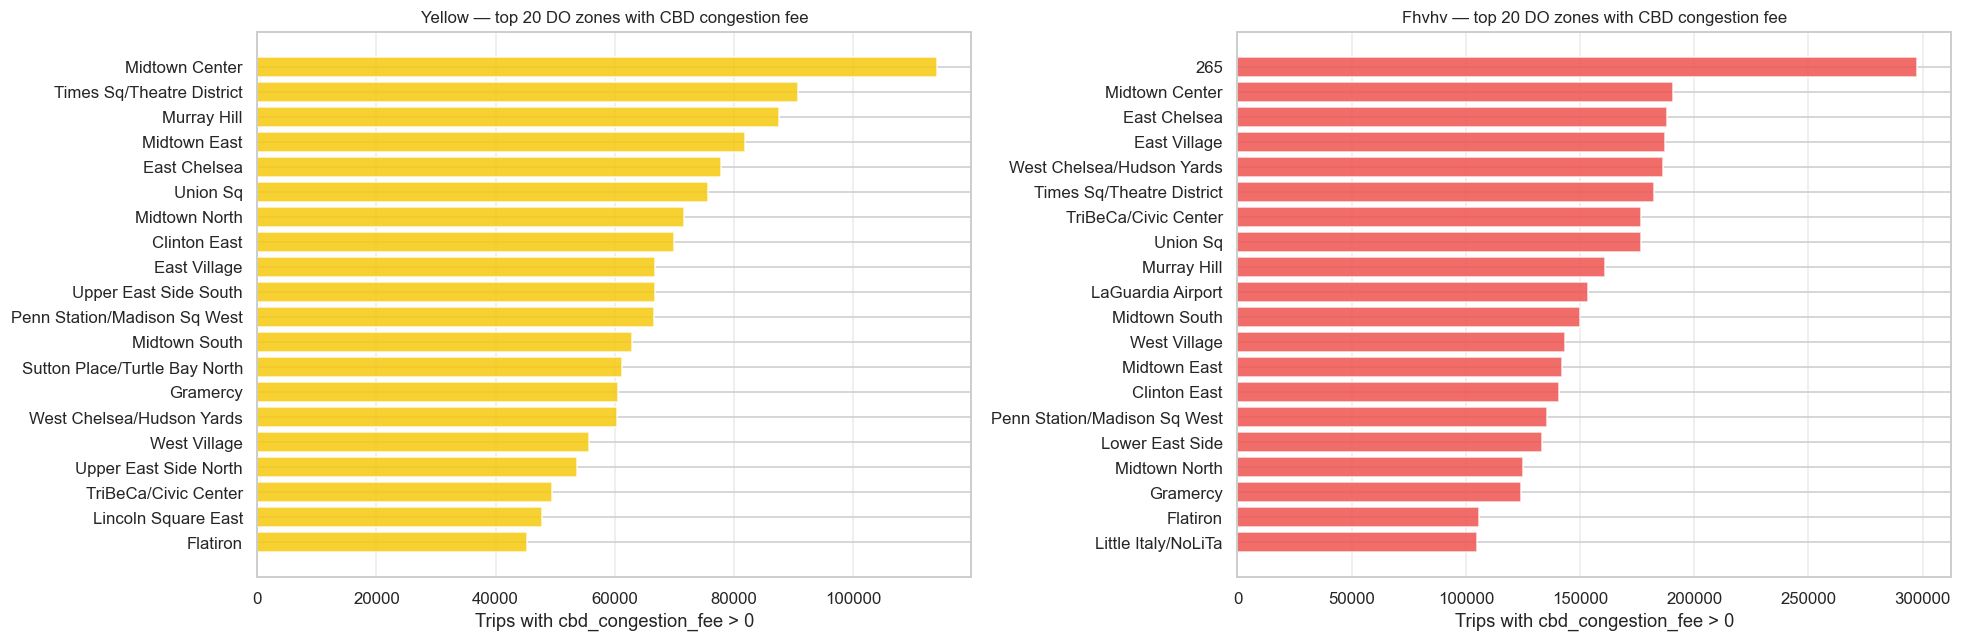

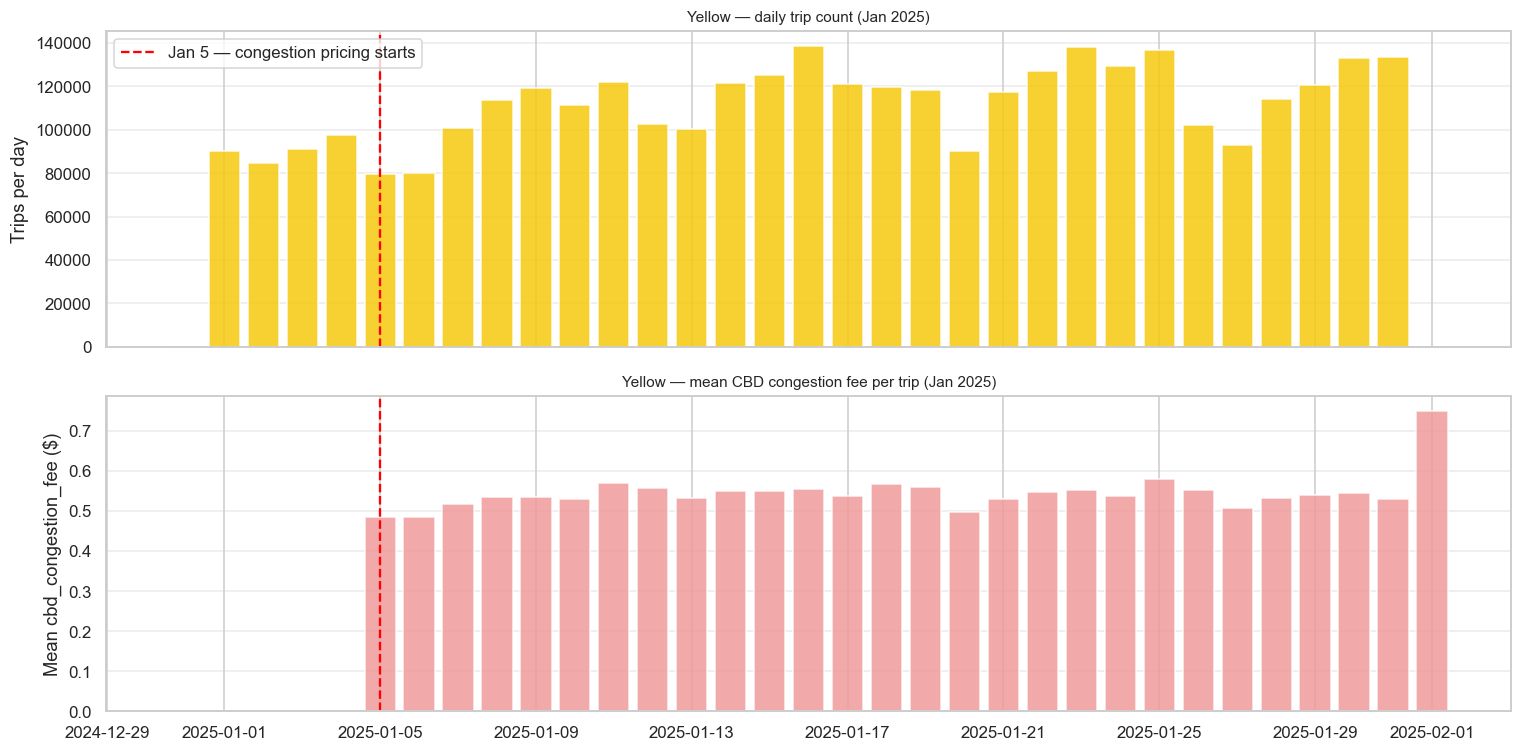

Pre-Jan 5  (   364,095 trips):  0.11% trips with CBD fee  |  mean fee on affected trips: $0.75
Post-Jan 5 ( 3,111,131 trips):  72.20% trips with CBD fee  |  mean fee on affected trips: $0.75


In [ ]:
CBD_FIELD       = "cbd_congestion_fee"
CONGESTION_DATE = pd.Timestamp("2025-01-05")

# Part 1 — Top-20 dropoff zones generating congestion-fee trips (yellow + fhvhv)
zone_names_12 = dict(zip(
    read_dbf_column(ZONES_DBF, "LocationID"),
    read_dbf_column(ZONES_DBF, "zone")
))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, fleet in zip(axes, ["yellow", "fhvhv"]):
    df = pd.read_parquet(FLEET[fleet], columns=[CBD_FIELD, "DOLocationID"]).dropna(subset=["DOLocationID"])
    df_fee = df[df[CBD_FIELD] > 0]
    vc = (df_fee["DOLocationID"].astype(int).value_counts()
          .nlargest(20).reset_index())
    vc.columns = ["LocationID", "trips"]
    vc["label"] = vc["LocationID"].map(zone_names_12).fillna(vc["LocationID"].astype(str))
    ax.barh(vc["label"], vc["trips"], color=FLEET_COLORS[fleet], alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(f"{fleet.title()} — top 20 DO zones with CBD congestion fee", fontsize=11)
    ax.set_xlabel("Trips with cbd_congestion_fee > 0")
    ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

# Part 2 — Pre/post Jan 5, 2025 step-change in yellow
df_y = pd.read_parquet(FLEET["yellow"],
                       columns=[PICKUP_COL["yellow"], CBD_FIELD]).dropna()
df_y["date"] = df_y[PICKUP_COL["yellow"]].dt.normalize()
daily = df_y.groupby("date").agg(
    trips    = (CBD_FIELD, "count"),
    mean_fee = (CBD_FIELD, "mean"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(daily["date"], daily["trips"],
            color=FLEET_COLORS["yellow"], alpha=0.85, width=0.8)
axes[0].axvline(CONGESTION_DATE, color="red", linestyle="--", linewidth=1.5,
                label="Jan 5 — congestion pricing starts")
axes[0].set_ylabel("Trips per day")
axes[0].set_title("Yellow — daily trip count (Jan 2025)", fontsize=10)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

axes[1].bar(daily["date"], daily["mean_fee"], color="#ef9a9a", alpha=0.85, width=0.8)
axes[1].axvline(CONGESTION_DATE, color="red", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("Mean cbd_congestion_fee ($)")
axes[1].set_title("Yellow — mean CBD congestion fee per trip (Jan 2025)", fontsize=10)
axes[1].grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

# Pre/post summary
pre = df_y[df_y[PICKUP_COL["yellow"]] <  CONGESTION_DATE]
post = df_y[df_y[PICKUP_COL["yellow"]] >= CONGESTION_DATE]
pre_pct = (pre[CBD_FIELD]  > 0).mean() * 100
post_pct = (post[CBD_FIELD] > 0).mean() * 100
pre_avg = pre[pre[CBD_FIELD]   > 0][CBD_FIELD].mean()
post_avg = post[post[CBD_FIELD] > 0][CBD_FIELD].mean()
print(f"Pre-Jan 5  ({len(pre):>10,} trips):  {pre_pct:.2f}% trips with CBD fee"
      f"  |  mean fee on affected trips: ${pre_avg:.2f}")
print(f"Post-Jan 5 ({len(post):>10,} trips):  {post_pct:.2f}% trips with CBD fee"
      f"  |  mean fee on affected trips: ${post_avg:.2f}")

**Key Finding — CBD Congestion Fee Characterization**

**The Jan 5 congestion pricing rollout is the single largest structural break in the January 2025 data.** Pre-Jan 5, only 0.11% of yellow trips carried a CBD fee; post-Jan 5, 72.20% do. The fee itself is fixed — $0.75 for metered, $1.50 for fhvhv (set by regulation, not data quality) — but it inflates `total_amount` for the majority of post-Jan 5 Manhattan-bound trips.

**Fleet coverage differs sharply:**
- **Yellow:** 64.64% of all January trips have the fee (2.25M trips) — yellow's Manhattan concentration means most trips enter the CBD.
- **FHVHV:** 30.87% (6.3M trips) — lower share because fhvhv serves more outer-borough routes that never enter the CBD, but higher absolute volume.
- **Green:** 7.11% (3.3K trips) — consistent with green's outer-borough focus; few trips reach the CBD.

**Top congestion-fee zones overlap heavily with the dinner zones from Task 7** — the Manhattan CBD is where both the restaurant-dense neighborhoods and the congestion pricing zone intersect. This makes `cbd_congestion_fee > 0` a potential binary feature for "trip entered a high-density restaurant area."

**Stage 2 actions:** (1) Subtract `cbd_congestion_fee` from `total_amount` before computing fare features to remove the confound. (2) Consider `cbd_congestion_fee > 0` as a binary CBD-entry feature — it marks trips that entered Manhattan's core dining district. (3) When using February 2025 data, the pre/post split no longer applies — 100% of trips are post-rollout.

## Task 15 - Fare-Per-Mile Normalization Feasibility

Compute `fare_per_mile = fare_amount / trip_distance` (yellow, taximeter) and `fare_per_mile = base_passenger_fare / trip_miles` (fhvhv, GPS). Plot side-by-side density histograms. If the distributions converge after per-mile normalization, a unified cross-fleet spend-intensity feature is feasible in Stage 2. If they remain bimodal or diverge, fare features must be kept group-specific.

Zero-distance trips and negative fares excluded before division. Distributions clipped at $20/mi to suppress long-haul outliers.

Fare-per-mile statistics (clipped at $20/mi):


,fare_field,dist_field,p25 ($/mi),median ($/mi),p75 ($/mi),mean ($/mi)
fleet,,,,,,
yellow,fare_amount,trip_distance,5.71,7.18,9.04,7.76
fhvhv,base_passenger_fare,trip_miles,4.42,6.25,8.75,7.16


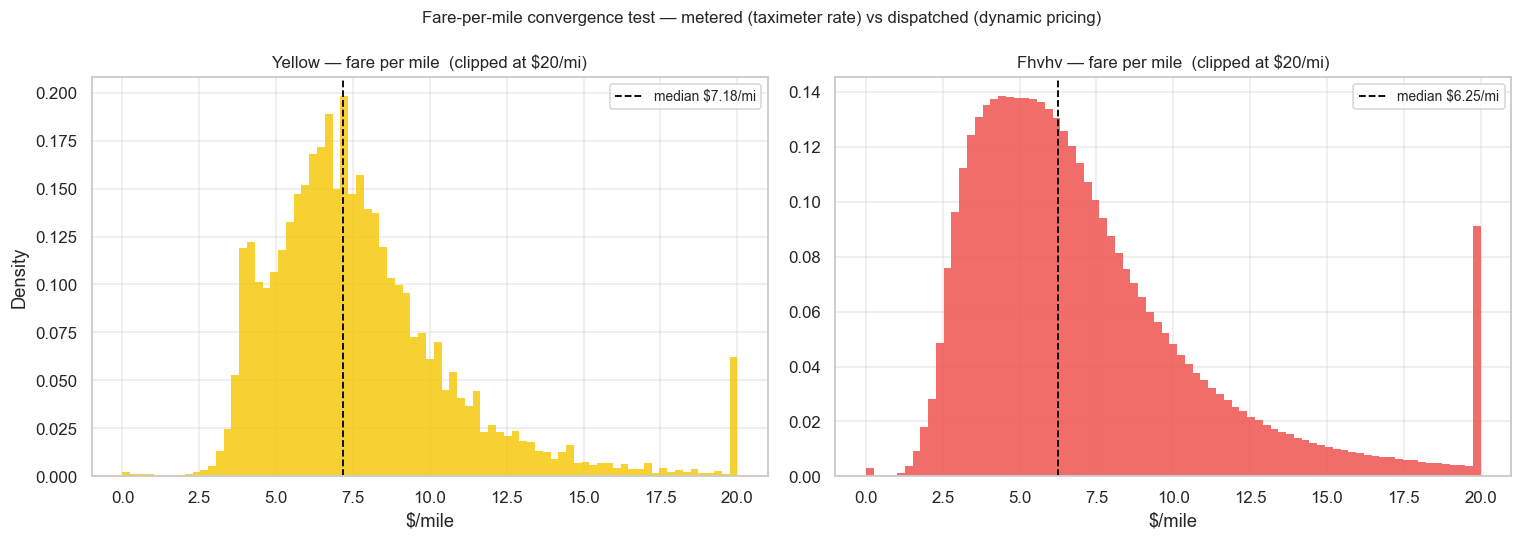

In [ ]:
import numpy as np

# Compute fare per mile — excludes zero/negative distance and negative fares
fpm_data  = {}
fpm_stats = []

for fleet, fare_col, dist_col in [
    ("yellow", "fare_amount",         "trip_distance"),
    ("fhvhv",  "base_passenger_fare", "trip_miles")
]:
    df = pd.read_parquet(FLEET[fleet], columns=[fare_col, dist_col]).dropna()
    df = df[(df[dist_col] > 0) & (df[fare_col] >= 0)]
    fpm = (df[fare_col] / df[dist_col]).clip(0, 20)   # clip at $20/mi
    fpm_data[fleet] = fpm
    fpm_stats.append({
        "fleet": fleet,
        "fare_field": fare_col,
        "dist_field": dist_col,
        "p25 ($/mi)": round(fpm.quantile(0.25), 2),
        "median ($/mi)": round(fpm.median(), 2),
        "p75 ($/mi)": round(fpm.quantile(0.75), 2),
        "mean ($/mi)": round(fpm.mean(), 2)
    })

print("Fare-per-mile statistics (clipped at $20/mi):")
display(pd.DataFrame(fpm_stats).set_index("fleet"))

# Side-by-side histogram (density normalised — comparable despite volume difference)
bins = np.linspace(0, 20, 80)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fleet in zip(axes, ["yellow", "fhvhv"]):
    fpm = fpm_data[fleet]
    ax.hist(fpm, bins=bins, color=FLEET_COLORS[fleet], alpha=0.85,
            edgecolor="none", density=True)
    ax.axvline(fpm.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"median ${fpm.median():.2f}/mi")
    ax.set_title(f"{fleet.title()} — fare per mile  (clipped at $20/mi)", fontsize=11)
    ax.set_xlabel("$/mile")
    ax.set_ylabel("Density" if fleet == "yellow" else "")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)

plt.suptitle(
    "Fare-per-mile convergence test — metered (taximeter rate) vs dispatched (dynamic pricing)",
    fontsize=11)
plt.tight_layout()
plt.show()

**Key Finding — Fare-Per-Mile Normalization Feasibility**

**Per-mile normalization largely closes the cross-group fare gap.** Raw median fares diverge by $5.89 ($12.11 yellow vs $18.00 fhvhv — Task 10), but after dividing by distance the medians converge to $7.18/mi (yellow) vs $6.25/mi (fhvhv) — a $0.93 gap, an 84% reduction. Means converge even further: $7.76 vs $7.16 (only $0.60 apart).

**IQR overlap is substantial:** yellow $5.71–$9.04/mi, fhvhv $4.42–$8.75/mi. The distributions are not identical — yellow's is tighter (IQR $3.33) while fhvhv's is wider (IQR $4.33), reflecting dynamic pricing variability — but they share the same central mass in the $4–$10/mi range.

**Verdict: a unified fare-per-mile feature is feasible for Stage 2.** The remaining $0.93/mi median gap is small enough that a single `fare_per_mile` feature can serve as a cross-fleet spend-intensity signal without requiring group-specific branches. However, the wider fhvhv IQR means the feature will be noisier for dispatched trips — Stage 2 should consider winsorizing at the 5th/95th percentiles to tame surge-pricing outliers.

This result confirms that the "analogous, not equivalent" label from Task 1 understates the degree of convergence after normalization. The pricing *models* differ (metered vs dynamic), but the *per-mile cost to the rider* is remarkably similar — consistent with competitive pressure between taxis and rideshare in the same market.